In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

warnings.filterwarnings('ignore')

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, RobustScaler, FunctionTransformer

from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, classification_report, confusion_matrix, roc_curve
from sklearn.metrics import precision_recall_curve, auc,precision_score, recall_score, matthews_corrcoef,log_loss
from sklearn.compose import ColumnTransformer

from sklearn import set_config
from sklearn import svm,metrics
from sklearn.naive_bayes import GaussianNB #Naive bayes
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer

from lightgbm import LGBMClassifier
import lightgbm as lgbm
from xgboost import XGBClassifier
import xgboost as xgb
from xgboost import plot_importance

#from tensorflow.keras import models, layers, Input

import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)
from scripts.Function_group import model_eval, ModelTuner
from scripts.feat_eng import apply_all

warnings.filterwarnings('ignore')
sns.set_theme(palette='pastel')

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 50)

In [2]:
# 한글 폰트 출력
import matplotlib.font_manager as fm

# 설치된 폰트 출력
font_list = [font.name for font in fm.fontManager.ttflist]
font_list

plt.rcParams['font.family'] = 'Pretendard'

#싸이킷런에서 인코딩 후 데이터를 판다스 데이터 프레임으로 남기기
set_config(transform_output="pandas")

In [3]:
# 데이터 불러오기
merchant_df = pd.read_csv('../data/raw/big_data_set1_f.csv', encoding='cp949')
sale_df = pd.read_csv('../data/raw/big_data_set2_f.csv', encoding='cp949')
cust_df = pd.read_csv('../data/raw/big_data_set3_f.csv', encoding='cp949')

In [4]:
## 컬럼명 변경
def rename_column(merchant_df, sale_df, cust_df):
    # merchant_df 컬럼명 변경
    merchant_df.columns = ['가맹점 구분번호', '가맹점 주소', '가맹점명', '브랜드 구분코드', '가맹점 지역', '업종', '상권', '개업일', '폐업일']

    # sale_df 컬럼명 변경
    sale_df.columns = ['가맹점 구분번호', '기준년월', '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간', '유니크 고객 수 구간', '객단가 구간', '취소율 구간', '배달매출금액 비율', 
                       '동일 업종 매출금액 비율', '동일 업종 매출건수 비율', '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율', '동일 업종 내 해지 가맹점 비중', '동일 상권 내 해지 가맹점 비중']
    # cust_df 컬럼명 변경
    cust_df.columns = ['가맹점 구분번호', '기준년월', '남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중', '남성 50대 고객 비중', '남성 60대이상 고객 비중', '여성 20대이하 고객 비중', 
                       '여성 30대 고객 비중', '여성 40대 고객 비중', '여성 50대 고객 비중', '여성 60대이상 고객 비중','재방문 고객 비중', '신규 고객 비중', '거주 이용 고객 비율', '직장 이용 고객 비율', '유동인구 이용 고객 비율']
    
    return merchant_df, sale_df, cust_df

rename_column(merchant_df, sale_df, cust_df)

(        가맹점 구분번호               가맹점 주소          가맹점명   브랜드 구분코드  가맹점 지역  \
 0     16184E93D9           서울 성동구 마장동          성우**        NaN  서울 성동구   
 1     4D039EA8B7           서울 성동구 마장동          대보**        NaN  서울 성동구   
 2     0074C4990A           서울 성동구 마장동          대용**        NaN  서울 성동구   
 3     68308F2746           서울 성동구 마장동          통일**        NaN  서울 성동구   
 4     4117EDDE9C           서울 성동구 마장동          한울**        NaN  서울 성동구   
 ...          ...                  ...           ...        ...     ...   
 4180  7FCF23E6F3    서울특별시 성동구 마장로 137  아이**********        NaN  서울 성동구   
 4181  9743B78531      서울 성동구 독서당로 223          어반**        NaN  서울 성동구   
 4182  C2261977A8  서울특별시 성동구 마장로35길 76          한성**        NaN  서울 성동구   
 4183  F1C69918DF      서울 성동구 왕십리로 410          국수**  한식-국수/만두3  서울 성동구   
 4184  58B8C943BF     서울특별시 성동구 매봉길 50      아이******        NaN  서울 성동구   
 
             업종   상권       개업일  폐업일  
 0          축산물  마장동  20130320  NaN  
 1          축산물  마장동  

# Feature Engineering

### 가맹점 데이터 전처리

In [5]:
## 가맹점 데이터 전처리
def preprocess_merchant(merchant_df):
    # 복사본 생성
    merchant_df_prc = merchant_df.copy()

    #개업일 자료형을 숫자에서 날짜형으로 변환
    merchant_df_prc['폐업 여부'] = merchant_df_prc['폐업일'].notna().astype(int)
    merchant_df_prc['개업일'] = pd.to_datetime(merchant_df_prc['개업일'],format="%Y%m%d") #개업일 날짜형으로 변환

    merchant_df_prc['폐업일'] = merchant_df_prc['폐업일'].fillna(20250901) #폐업일을 2025년 9월 1일로 채움
    merchant_df_prc['폐업일'] = pd.to_datetime(merchant_df_prc['폐업일'],format="%Y%m%d") #폐업일 날짜형으로 변환
    
    merchant_df_prc['개업 기간'] = (merchant_df_prc['폐업일'] - merchant_df_prc['개업일']).dt.days #개업 기간 기준을 2025년 9월 1일까지로 정함 - 정말로 필요한 데이터일까?
    
    
    ## 업종 그룹화 
    meat = ['한식-육류/고기',  '꼬치구이']
    cafe = ['카페',  '주스',  '차',  '테마카페',  '커피전문점', '테이크아웃커피',  '구내식당/푸드코트']
    k_food = ['백반/가정식',  '기사식당', '한식-두부요리', '한식-단품요리일반',  '한정식',    '한식-죽',  '한식-국수/만두',  '한식-국밥/설렁탕',  '한식-찌개/전골',  '한식-냉면',  '한식뷔페',  '한식-감자탕',   '한식-해물/생선']
    w_food = ['양식',  '스테이크', '치킨',  '햄버거',  '피자']
    j_food = ['일식당',  '일식-우동/소바/라면',  '일식-초밥/롤',  '일식-덮밥/돈가스',  '일식-샤브샤브',  '일식-참치회']
    c_food = ['중식당',  '중식-딤섬/중식만두',  '중식-훠궈/마라탕']
    drink = ['호프/맥주',  '요리주점',  '민속주점',  '포장마차',  '이자카야',  '와인바', '주류',  '와인샵']
    product= ['농산물',  '청과물',  '수산물',  '건어물',  '축산물']
    enter = ['일반 유흥주점',  '룸살롱/단란주점']
    convenience = ['샌드위치/토스트',  '도시락', '분식']
    world_food = ['동남아/인도음식',  '기타세계요리']
    dessert = ['도너츠',  '탕후루',  '와플/크로플',  '마카롱',  '아이스크림/빙수',  '떡/한과',  '떡/한과 제조',  '베이커리']
    others = ['식품 제조',  '반찬',  '미곡상',  '유제품',  '인삼제품', '건강식품', '건강원', '담배',  '식료품']

    # replace 진행
    groups_to_replace = [(meat, '육류'), (cafe, '카페'), (k_food, '한식'), (w_food, '양식'), (j_food, '일식'),
                         (c_food, '중식'), (drink, '주점'), (product, '농수축산물'), (enter, '유흥업소'), (convenience, '간편식'),
                         (world_food, '이색요리'), (dessert, '디저트'), (others, '기타')]
    
    replacement = {}
    for ind, cat in groups_to_replace:
        for i in ind:
            replacement[i] = cat

    merchant_df_prc['업종'].replace(replacement, inplace=True)

    ## 상권 그룹화
    # 상권 데이터 1개만 존재하는 경우 주변 상권과 통합 (장한평자동차와 답십리는 모두 구석진 곳인데 가까우므로 결합)
    areas_to_replace = {'화양시장': '성수', '자양': '성수', '서면역': '성수', '미아사거리': '성수',
                        '방배역': '뚝섬', '건대입구': '뚝섬', '풍산지구': '뚝섬', '오남': '한양대',
                        '동대문역사문화공원역': '금남시장',  '압구정로데오': '금남시장',  '장한평자동차': '답십리'}
    
    merchant_df_prc['상권'].replace(areas_to_replace, inplace=True)

    # 상권 결측치는 Unknown으로 대체
    merchant_df_prc['상권'].fillna('Unknown', inplace=True)
    
    return merchant_df_prc

merchant_df_prc = preprocess_merchant(merchant_df)
merchant_df_prc['개업 기간']

0       4548
1       4301
2       4130
3       3569
4       3552
        ... 
4180     742
4181    4563
4182     838
4183    1425
4184     913
Name: 개업 기간, Length: 4185, dtype: int64

#### sale_df, cust_df 병합

In [6]:
merged_df = sale_df.merge(cust_df, on=['가맹점 구분번호','기준년월'])

### 월별 가맹점 정보 전처리

In [7]:
def preprocess_merged(merged_df):
    # 복사본 생성
    merged_df_prc = merged_df.copy()

    # 구간 데이터 앞에 숫자만 빼오기
    merged_df_prc.loc[:, '가맹점 운영개월수 구간':'취소율 구간'] = merged_df_prc.loc[:, '가맹점 운영개월수 구간':'취소율 구간'].apply(lambda x: x.str.split('_', expand=True)[0])
    
    # 구간 데이터들의 자료형 int형으로 변환
    # 가정: 결측값의 경우 취소율이 적다고 판단!!
    band_cols = merged_df_prc.loc[:, '가맹점 운영개월수 구간':'객단가 구간'].columns
    merged_df_prc[band_cols] = merged_df_prc[band_cols].astype(int)
    
    ## 비율 데이터 전처리
    # 배달매출금액 비율의 -999999.9는 배달매출 미존재 의미 => 0으로 대체 가능 (배달매출금액 비율이 처음부터 0인 데이터도 있긴 함)
    merged_df_prc['배달매출금액 비율'] = merged_df_prc['배달매출금액 비율'].map(lambda x: 0 if x < 0 else x)

    # 동일 상권 내 해지 가맹점 비중의 -999999.9는 상권 미존재 의미 => 100으로 할 수 도 있겠으나 일단 0으로 대체
    merged_df_prc['동일 상권 내 해지 가맹점 비중'] = merged_df_prc['동일 상권 내 해지 가맹점 비중'].map(lambda x: 0 if x < 0 else x)

    # 결측치 최빈값으로 대체 후 구간 데이터들의 자료형 int형으로 변환
    # 가정: 결측값의 경우 취소율이 적다고 판단!!
    band_cols = merged_df_prc.loc[:, '가맹점 운영개월수 구간':'취소율 구간'].columns
    merged_df_prc[band_cols] = merged_df_prc[band_cols].replace(-999999.9,np.nan)

    # 결측치는 0으로 대체
    cust_cols = merged_df_prc.iloc[:, 15:].columns
    merged_df_prc[cust_cols] = merged_df_prc[cust_cols].replace(-999999.9,np.nan)

    # 방문 비율 100%로 맞춤
    merged_df_prc['방문 총합'] =  (merged_df_prc['재방문 고객 비중'] + merged_df_prc['신규 고객 비중'])
    merged_df_prc['재방문 고객 비중'] = 100*merged_df_prc['재방문 고객 비중']/merged_df_prc['방문 총합']
    merged_df_prc['신규 고객 비중'] = 100*merged_df_prc['신규 고객 비중']/merged_df_prc['방문 총합']
    merged_df_prc = merged_df_prc.drop(columns = ['방문 총합'])

    #기준년월 날짜형으로 변환
    merged_df_prc['기준년월'] = pd.to_datetime(merged_df_prc['기준년월'],format="%Y%m")
    # cust_df_prc 데이터 merged_df에 추가

    #취소율 구간 행 제거
    merged_df_prc = merged_df_prc.drop(columns=['취소율 구간'])
    
    return merged_df_prc

merged_df_prc = preprocess_merged(merged_df)

In [8]:
null_count = pd.concat([merged_df_prc.isnull().sum(),merged_df_prc[merged_df_prc['거주 이용 고객 비율'].isnull()].isnull().sum(),merged_df_prc[merged_df_prc['동일 업종 매출금액 비율'] == 0].isnull().sum()],axis=1)
null_count.columns = ['전체 데이터에서 결측치 통계','거주 이용 고객 비율이 결측치일때 결측치 통계','동일 업종 매출금액 비율이 0일 때 결측치 통계']
null_count

,전체 데이터에서 결측치 통계,거주 이용 고객 비율이 결측치일때 결측치 통계,동일 업종 매출금액 비율이 0일 때 결측치 통계
가맹점 구분번호,0,0,0
기준년월,0,0,0
가맹점 운영개월수 구간,0,0,0
매출금액 구간,0,0,0
매출건수 구간,0,0,0
유니크 고객 수 구간,0,0,0
객단가 구간,0,0,0
배달매출금액 비율,0,0,0
동일 업종 매출금액 비율,0,0,0
동일 업종 매출건수 비율,0,0,0


In [9]:
#merged_df_prc = merged_df_prc[merged_df_prc['동일 업종 매출금액 비율'] != 0]

In [11]:
merchant_df_prc

,가맹점 구분번호,가맹점 주소,가맹점명,브랜드 구분코드,가맹점 지역,업종,상권,개업일,폐업일,폐업 여부,개업 기간
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,농수축산물,마장동,2013-03-20,2025-09-01,0,4548
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,농수축산물,마장동,2013-11-22,2025-09-01,0,4301
2,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,농수축산물,마장동,2014-05-12,2025-09-01,0,4130
3,68308F2746,서울 성동구 마장동,통일**,NaN,서울 성동구,농수축산물,마장동,2015-11-24,2025-09-01,0,3569
4,4117EDDE9C,서울 성동구 마장동,한울**,NaN,서울 성동구,농수축산물,마장동,2015-12-11,2025-09-01,0,3552
...,...,...,...,...,...,...,...,...,...,...,...
4180,7FCF23E6F3,서울특별시 성동구 마장로 137,아이**********,NaN,서울 성동구,디저트,Unknown,2023-08-21,2025-09-01,0,742
4181,9743B78531,서울 성동구 독서당로 223,어반**,NaN,서울 성동구,양식,Unknown,2013-03-05,2025-09-01,0,4563
4182,C2261977A8,서울특별시 성동구 마장로35길 76,한성**,NaN,서울 성동구,농수축산물,Unknown,2023-05-17,2025-09-01,0,838
4183,F1C69918DF,서울 성동구 왕십리로 410,국수**,한식-국수/만두3,서울 성동구,한식,Unknown,2021-10-07,2025-09-01,0,1425


In [12]:
simple_mc_df = merchant_df_prc[['가맹점 구분번호','폐업 여부']]
total_df = merged_df_prc.merge(simple_mc_df,on = '가맹점 구분번호')
total_df = total_df.sort_values(by=['기준년월'])

total_df = total_df.drop(columns=['남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중', '남성 50대 고객 비중', 
                                '남성 60대이상 고객 비중', '여성 20대이하 고객 비중', '여성 30대 고객 비중', '여성 40대 고객 비중', 
                       '여성 50대 고객 비중', '여성 60대이상 고객 비중','재방문 고객 비중', '신규 고객 비중', '거주 이용 고객 비율', 
                       '직장 이용 고객 비율', '유동인구 이용 고객 비율','동일 업종 내 해지 가맹점 비중','동일 상권 내 해지 가맹점 비중','배달매출금액 비율',
                       '가맹점 운영개월수 구간'])

recent3 = total_df.sort_values(by=['기준년월']).groupby('가맹점 구분번호').tail(3)

recent3 = recent3.groupby('가맹점 구분번호').filter(lambda x: (len(x) >= 3) or (x['폐업 여부'].iloc[0] != 0))

mc_id = recent3['가맹점 구분번호'] #사용할 데이터 

result_df = recent3.groupby('가맹점 구분번호').mean(numeric_only=True).reset_index()

band_cols = result_df.loc[:,'매출금액 구간':'객단가 구간'].columns

for i in band_cols:
    result_df[i] = result_df[i].round(0)

result_df = result_df.drop(columns = ['폐업 여부'])

result_df.columns = ['가맹점 구분번호','최근 3개월 매출 금액 구간 평균','최근 3개월 매출건수 구간 평균','최근 3개월 유니크 고객 수 구간 평균',
                     '최근 3개월 객단가 구간 평균','최근 3개월 동일 업종 매출금액 비율 평균',
                     '최근 3개월 동일 업종 매출건수 비율 평균','최근 3개월 동일 업종 내 매출 순위 비율 평균','최근 3개월 동일 상권 내 매출 순위 비율 평균']
result_df

,가맹점 구분번호,최근 3개월 매출 금액 구간 평균,최근 3개월 매출건수 구간 평균,최근 3개월 유니크 고객 수 구간 평균,최근 3개월 객단가 구간 평균,최근 3개월 동일 업종 매출금액 비율 평균,최근 3개월 동일 업종 매출건수 비율 평균,최근 3개월 동일 업종 내 매출 순위 비율 평균,최근 3개월 동일 상권 내 매출 순위 비율 평균
0,000F03E44A,6.0,5.0,5.0,5.0,1.066667,3.000000,86.966667,62.666667
1,002816BA73,3.0,4.0,4.0,2.0,104.400000,53.966667,18.300000,19.933333
2,003473B465,6.0,6.0,6.0,6.0,0.000000,0.000000,95.700000,88.033333
3,003AC99735,2.0,1.0,1.0,6.0,273.366667,521.633333,3.500000,9.666667
4,0041E4E5AE,2.0,2.0,2.0,4.0,217.033333,427.200000,8.366667,9.166667
...,...,...,...,...,...,...,...,...,...
4112,FF8A45E182,2.0,2.0,2.0,3.0,166.466667,231.400000,12.800000,0.000000
4113,FFAC8CC0F7,6.0,6.0,6.0,5.0,0.300000,0.500000,43.533333,37.100000
4114,FFD5654C3D,3.0,3.0,2.0,3.0,136.733333,244.200000,13.400000,30.100000
4115,FFEDAC5747,1.0,1.0,1.0,5.0,267.733333,334.766667,5.200000,0.000000


In [13]:
recent6 = total_df.sort_values(by=['기준년월']).groupby('가맹점 구분번호').tail(6)

recent6 = recent6[recent6['가맹점 구분번호'].isin(mc_id)]

result2_df = recent6.groupby('가맹점 구분번호').mean(numeric_only=True).reset_index()

band_cols = result2_df.loc[:,'매출금액 구간':'객단가 구간'].columns

for i in band_cols:
    result2_df[i] = result2_df[i].round(0)

result2_df = result2_df.drop(columns = ['폐업 여부'])

result2_df.columns = ['가맹점 구분번호','최근 6개월 매출 금액 구간 평균','최근 6개월 매출건수 구간 평균','최근 6개월 유니크 고객 수 구간 평균',
                     '최근 6개월 객단가 구간 평균','최근 6개월 동일 업종 매출금액 비율 평균',
                     '최근 6개월 동일 업종 매출건수 비율 평균','최근 6개월 동일 업종 내 매출 순위 비율 평균','최근 6개월 동일 상권 내 매출 순위 비율 평균']

result2_df

,가맹점 구분번호,최근 6개월 매출 금액 구간 평균,최근 6개월 매출건수 구간 평균,최근 6개월 유니크 고객 수 구간 평균,최근 6개월 객단가 구간 평균,최근 6개월 동일 업종 매출금액 비율 평균,최근 6개월 동일 업종 매출건수 비율 평균,최근 6개월 동일 업종 내 매출 순위 비율 평균,최근 6개월 동일 상권 내 매출 순위 비율 평균
0,000F03E44A,6.0,5.0,5.0,4.0,2.116667,2.566667,87.700000,63.900000
1,002816BA73,3.0,4.0,4.0,2.0,109.350000,52.300000,17.150000,19.916667
2,003473B465,6.0,6.0,6.0,6.0,0.000000,0.000000,95.900000,87.916667
3,003AC99735,2.0,1.0,1.0,6.0,273.033333,509.816667,3.633333,9.733333
4,0041E4E5AE,2.0,2.0,2.0,4.0,192.100000,397.750000,7.800000,8.900000
...,...,...,...,...,...,...,...,...,...
4112,FF8A45E182,3.0,3.0,2.0,3.0,156.433333,207.133333,12.600000,0.000000
4113,FFAC8CC0F7,6.0,6.0,6.0,6.0,0.150000,0.250000,35.383333,32.533333
4114,FFD5654C3D,3.0,3.0,3.0,3.0,124.516667,220.466667,12.633333,30.083333
4115,FFEDAC5747,1.0,1.0,1.0,5.0,268.383333,336.650000,5.233333,0.000000


In [14]:
grouped = total_df.sort_values(by=['가맹점 구분번호', '기준년월'])
grouped = grouped[grouped['가맹점 구분번호'].isin(mc_id)]

store_features = total_df.drop_duplicates('가맹점 구분번호', keep='first').reset_index(drop = True)

for col in ['매출금액 구간', '매출건수 구간', '유니크 고객 수 구간','객단가 구간']: 
   
    grouped[f'{col}_1개월전'] = grouped.groupby('가맹점 구분번호')[col].shift(1)
    grouped[f'{col}_3개월전'] = grouped.groupby('가맹점 구분번호')[col].shift(3)
    grouped[f'{col}_6개월전'] = grouped.groupby('가맹점 구분번호')[col].shift(6)
    grouped[f'{col}_12개월전'] = grouped.groupby('가맹점 구분번호')[col].shift(12)

store_features = grouped.drop_duplicates('가맹점 구분번호', keep='last').reset_index(drop = True)  
store_features = store_features.drop(columns = ['폐업 여부'])

store_features


,가맹점 구분번호,기준년월,매출금액 구간,매출건수 구간,유니크 고객 수 구간,객단가 구간,동일 업종 매출금액 비율,동일 업종 매출건수 비율,동일 업종 내 매출 순위 비율,동일 상권 내 매출 순위 비율,매출금액 구간_1개월전,매출금액 구간_3개월전,매출금액 구간_6개월전,매출금액 구간_12개월전,매출건수 구간_1개월전,매출건수 구간_3개월전,매출건수 구간_6개월전,매출건수 구간_12개월전,유니크 고객 수 구간_1개월전,유니크 고객 수 구간_3개월전,유니크 고객 수 구간_6개월전,유니크 고객 수 구간_12개월전,객단가 구간_1개월전,객단가 구간_3개월전,객단가 구간_6개월전,객단가 구간_12개월전
0,000F03E44A,2024-12-01,6,5,5,5,0.7,4.1,86.8,62.8,6.0,5.0,5.0,6.0,5.0,5.0,5.0,6.0,5.0,5.0,5.0,6.0,5.0,2.0,3.0,6.0
1,002816BA73,2024-12-01,3,4,4,2,113.5,67.1,21.5,20.0,3.0,3.0,4.0,2.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,3.0,2.0,2.0,2.0,2.0
2,003473B465,2024-12-01,6,6,6,6,0.0,0.0,94.9,88.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0
3,003AC99735,2024-12-01,3,1,1,6,254.3,549.1,3.2,9.7,2.0,2.0,2.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,6.0,6.0,6.0,5.0
4,0041E4E5AE,2024-12-01,2,2,2,4,218.4,425.7,9.6,9.1,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,4.0,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4112,FF8A45E182,2024-12-01,3,3,2,3,130.0,230.3,14.6,0.0,2.0,3.0,3.0,3.0,2.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,3.0,3.0
4113,FFAC8CC0F7,2024-12-01,6,5,5,3,0.9,1.5,55.1,41.5,6.0,6.0,5.0,3.0,6.0,6.0,5.0,2.0,6.0,6.0,5.0,2.0,6.0,6.0,1.0,4.0
4114,FFD5654C3D,2024-12-01,3,3,3,3,119.6,193.9,15.9,30.8,3.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,3.0,3.0,2.0,4.0,3.0,3.0,3.0
4115,FFEDAC5747,2024-12-01,1,1,1,4,239.9,308.2,5.1,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,4.0,5.0,4.0


In [15]:
merchant_df_prc = merchant_df_prc.drop(columns = ['가맹점 주소','가맹점명','브랜드 구분코드','개업일','폐업일','가맹점 지역'])


In [16]:
final_df = merchant_df_prc.merge(store_features, on = '가맹점 구분번호')
final_df = final_df.merge(result_df, on = '가맹점 구분번호')
final_df = final_df.merge(result2_df, on = '가맹점 구분번호')
final_df = final_df.drop(columns = ['가맹점 구분번호','기준년월'])
final_df = final_df.replace(np.nan,0)

final_df

,업종,상권,폐업 여부,개업 기간,매출금액 구간,매출건수 구간,유니크 고객 수 구간,객단가 구간,동일 업종 매출금액 비율,동일 업종 매출건수 비율,동일 업종 내 매출 순위 비율,동일 상권 내 매출 순위 비율,매출금액 구간_1개월전,매출금액 구간_3개월전,매출금액 구간_6개월전,매출금액 구간_12개월전,매출건수 구간_1개월전,매출건수 구간_3개월전,매출건수 구간_6개월전,매출건수 구간_12개월전,유니크 고객 수 구간_1개월전,유니크 고객 수 구간_3개월전,유니크 고객 수 구간_6개월전,유니크 고객 수 구간_12개월전,객단가 구간_1개월전,객단가 구간_3개월전,객단가 구간_6개월전,객단가 구간_12개월전,최근 3개월 매출 금액 구간 평균,최근 3개월 매출건수 구간 평균,최근 3개월 유니크 고객 수 구간 평균,최근 3개월 객단가 구간 평균,최근 3개월 동일 업종 매출금액 비율 평균,최근 3개월 동일 업종 매출건수 비율 평균,최근 3개월 동일 업종 내 매출 순위 비율 평균,최근 3개월 동일 상권 내 매출 순위 비율 평균,최근 6개월 매출 금액 구간 평균,최근 6개월 매출건수 구간 평균,최근 6개월 유니크 고객 수 구간 평균,최근 6개월 객단가 구간 평균,최근 6개월 동일 업종 매출금액 비율 평균,최근 6개월 동일 업종 매출건수 비율 평균,최근 6개월 동일 업종 내 매출 순위 비율 평균,최근 6개월 동일 상권 내 매출 순위 비율 평균
0,농수축산물,마장동,0,4548,3,4,4,1,71.4,28.8,27.2,20.1,4.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0,4.0,1.0,1.0,1.0,2.0,3.0,4.0,4.0,1.0,67.333333,28.033333,27.166667,20.533333,3.0,4.0,4.0,2.0,68.166667,30.733333,27.100000,20.783333
1,농수축산물,마장동,0,4301,2,4,4,1,111.8,30.0,21.4,16.5,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,1.0,1.0,1.0,3.0,4.0,4.0,2.0,79.700000,28.266667,21.466667,16.900000,3.0,4.0,4.0,1.0,71.233333,27.300000,19.500000,15.766667
2,농수축산물,마장동,0,4130,2,4,4,1,134.7,58.8,14.6,11.6,2.0,2.0,3.0,5.0,4.0,4.0,4.0,5.0,4.0,4.0,4.0,5.0,2.0,1.0,2.0,3.0,2.0,4.0,4.0,1.0,146.900000,59.500000,16.033333,12.600000,3.0,4.0,4.0,1.0,108.950000,45.533333,16.016667,13.183333
3,농수축산물,마장동,0,3569,4,5,5,1,39.6,1.2,67.8,48.3,6.0,6.0,6.0,6.0,5.0,6.0,6.0,6.0,5.0,6.0,6.0,6.0,3.0,6.0,6.0,6.0,5.0,5.0,5.0,2.0,24.200000,1.666667,71.000000,51.700000,5.0,5.0,5.0,3.0,17.250000,1.066667,75.433333,56.950000
4,농수축산물,마장동,0,3552,5,5,5,1,3.5,1.2,83.6,67.8,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,4.0,1.166667,0.400000,92.133333,83.000000,6.0,6.0,6.0,5.0,0.583333,0.200000,94.300000,87.016667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4112,디저트,Unknown,0,742,4,2,3,6,42.8,232.9,12.3,0.0,4.0,4.0,4.0,4.0,2.0,1.0,2.0,3.0,2.0,2.0,2.0,3.0,6.0,5.0,5.0,5.0,4.0,2.0,2.0,6.0,55.066667,255.500000,13.100000,0.000000,4.0,1.0,2.0,5.0,66.883333,271.816667,14.433333,0.000000
4113,양식,Unknown,0,4563,1,3,3,2,189.8,175.0,6.2,0.0,2.0,2.0,1.0,1.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,3.0,3.0,1.0,3.0,3.0,2.0,215.466667,179.600000,6.200000,0.000000,1.0,3.0,2.0,2.0,231.766667,186.783333,6.200000,0.000000
4114,농수축산물,Unknown,0,838,1,4,4,1,225.6,62.4,3.1,0.0,2.0,1.0,2.0,1.0,4.0,3.0,4.0,4.0,4.0,3.0,4.0,4.0,1.0,1.0,1.0,1.0,2.0,4.0,4.0,1.0,173.233333,56.133333,3.000000,0.000000,1.0,4.0,4.0,1.0,318.966667,67.800000,2.866667,0.000000
4115,한식,Unknown,0,1425,4,3,3,4,62.6,160.3,26.1,0.0,3.0,3.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,4.0,86.900000,189.566667,23.000000,0.000000,3.0,2.0,3.0,4.0,86.383333,188.800000,22.383333,0.000000


### 범주형 데이터 그룹화
- 업종 통합 시 sale_df의 업종관련 정보와의 차이 발생 가능

### is_closed 컬럼 생성

### 불필요 컬럼 제거

In [ ]:
# 피쳐 엔지니어링
#final_df = apply_all(merchant_df, sale_df, cust_df)

In [ ]:
# plt.figure(figsize=(15, 10))
# test = merged_df.copy()
# test.drop(['sale_amt_band', 'unique_customer_band', 'industry_sale_cnt_ratio', 'industry_sale_rank_pct'], axis=1, inplace=True)
# sns.heatmap(test.select_dtypes(exclude='object').corr(), annot=True, fmt='.1f', cmap='RdBu')
# plt.show()

In [ ]:
## ModelTuner 사용법

'''
#사용가능한 모델
logistic,knn,gnb,svc_linear,svc_rbf,xgb,lgbm

#모델 생성 및 데이터 입력
logistic_tuner = ModelTuner('logistic',X_train, X_test,y_train,y_test)
xgb_tuner = ModelTuner('xgb',X_train, X_test,y_train,y_test)

#모델 튜닝 및 평가
#tune_evals은 생략 가능
logistic_tuner.run(tune_evals=50)

#튜닝된 모델
logistic_tuner.final_model()

#최적의 파라미터
logistic_tuner.best_params()

#모델 성능 지표
logistic_tuner.evaluate()

'''

"\n#사용가능한 모델\nlogistic,knn,gnb,svc_linear,svc_rbf,xgb,lgbm\n\n#모델 생성 및 데이터 입력\nlogistic_tuner = ModelTuner('logistic',X_train, X_test,y_train,y_test)\nxgb_tuner = ModelTuner('xgb',X_train, X_test,y_train,y_test)\n\n#모델 튜닝 및 평가\n#tune_evals은 생략 가능\nlogistic_tuner.run(tune_evals=50)\n\n#튜닝된 모델\nlogistic_tuner.final_model()\n\n#최적의 파라미터\nlogistic_tuner.best_params()\n\n#모델 성능 지표\nlogistic_tuner.evaluate()\n\n"

### 인코딩

In [17]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4117 entries, 0 to 4116
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   업종                          4117 non-null   object 
 1   상권                          4117 non-null   object 
 2   폐업 여부                       4117 non-null   int64  
 3   개업 기간                       4117 non-null   int64  
 4   매출금액 구간                     4117 non-null   int64  
 5   매출건수 구간                     4117 non-null   int64  
 6   유니크 고객 수 구간                 4117 non-null   int64  
 7   객단가 구간                      4117 non-null   int64  
 8   동일 업종 매출금액 비율               4117 non-null   float64
 9   동일 업종 매출건수 비율               4117 non-null   float64
 10  동일 업종 내 매출 순위 비율            4117 non-null   float64
 11  동일 상권 내 매출 순위 비율            4117 non-null   float64
 12  매출금액 구간_1개월전                4117 non-null   float64
 13  매출금액 구간_3개월전                4117 

In [18]:
y = final_df['폐업 여부']
X = final_df.drop(columns = ['폐업 여부'])


In [19]:
#학습, 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(exclude=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features), # 숫자형 컬럼은 StandardScaling
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False), categorical_features)  # 범주형 컬럼은 OneHotEncoding
    ])
#주의: 테스트 셋에서 학습 데이터에 없는 값들이 무시될 수 있음 handle_unknown='ignore' 없는 것도 적용해 볼것
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)#학습, 검증 데이터 셋 분리

In [88]:
X_train.shape

(3207, 88)

### Logistic Regression

--- Logistic Regression 모델 평가 ---
정확도(Accuracy): 0.9806
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



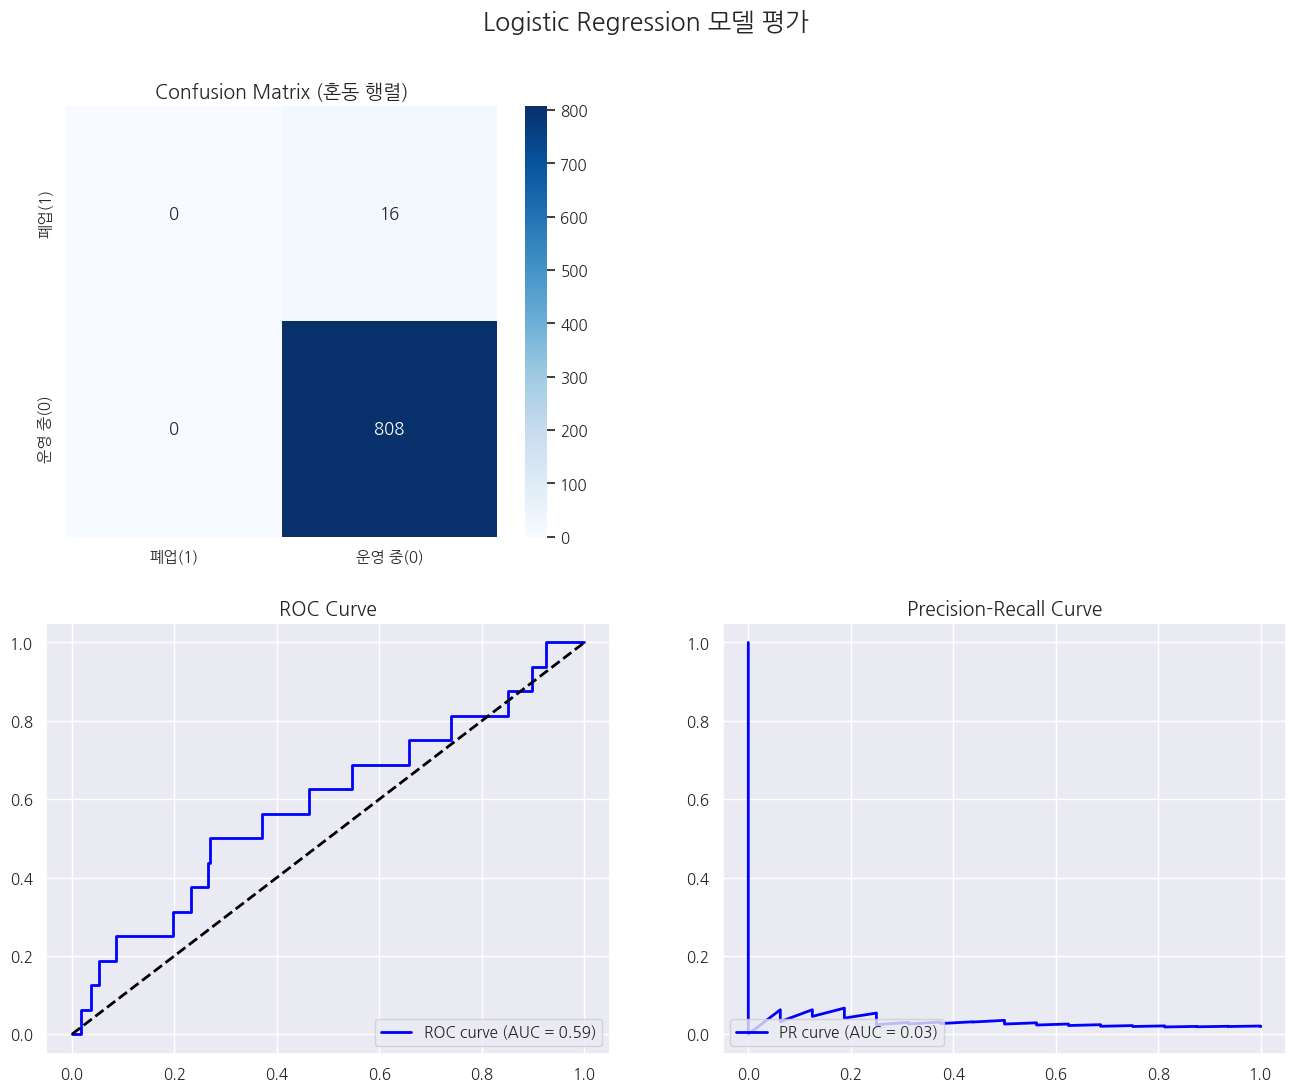

In [20]:
#Logistic Regression
model = LogisticRegression()
model.fit(X_train,y_train)

model_eval(model,"Logistic Regression",X_test,y_test)

--- logistic 모델의 하이퍼파라미터 튜닝 시작 ---
100%|██████████| 50/50 [00:50<00:00,  1.01s/trial, best loss: -0.73]              
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'C': np.float64(0.011792164096840562), 'class_weight': 'balanced', 'max_iter': np.float64(400.0), 'penalty': 'l1', 'solver': 'liblinear'}


최종 모델 학습 완료.
--- LOGISTIC 모델 평가 ---
정확도(Accuracy): 0.4800
정밀도(Precision): 0.0419
재현율(Recall): 0.7826
F1 점수(F1 Score): 0.0795
매튜 상관 계수(MCC): 0.0849



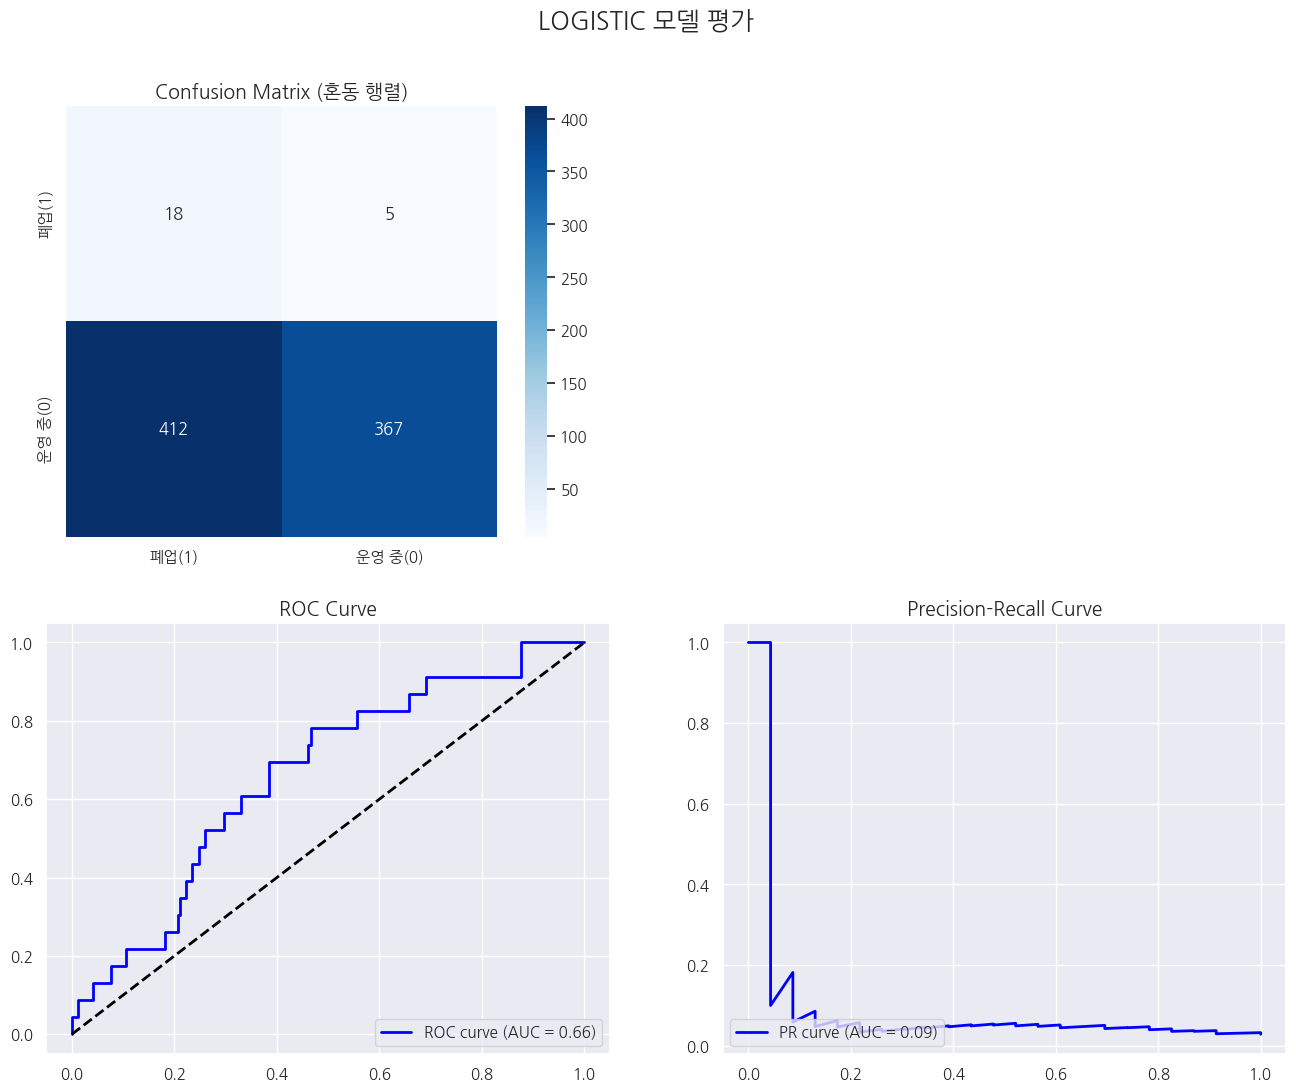

In [109]:
ModelTuner('logistic',X_train, X_test,y_train,y_test).run()

### Gaussian Naive Bayes

--- Gaussian Naive Bayes 모델 평가 ---
정확도(Accuracy): 0.1828
정밀도(Precision): 0.0299
재현율(Recall): 0.8750
F1 점수(F1 Score): 0.0579
매튜 상관 계수(MCC): 0.0170



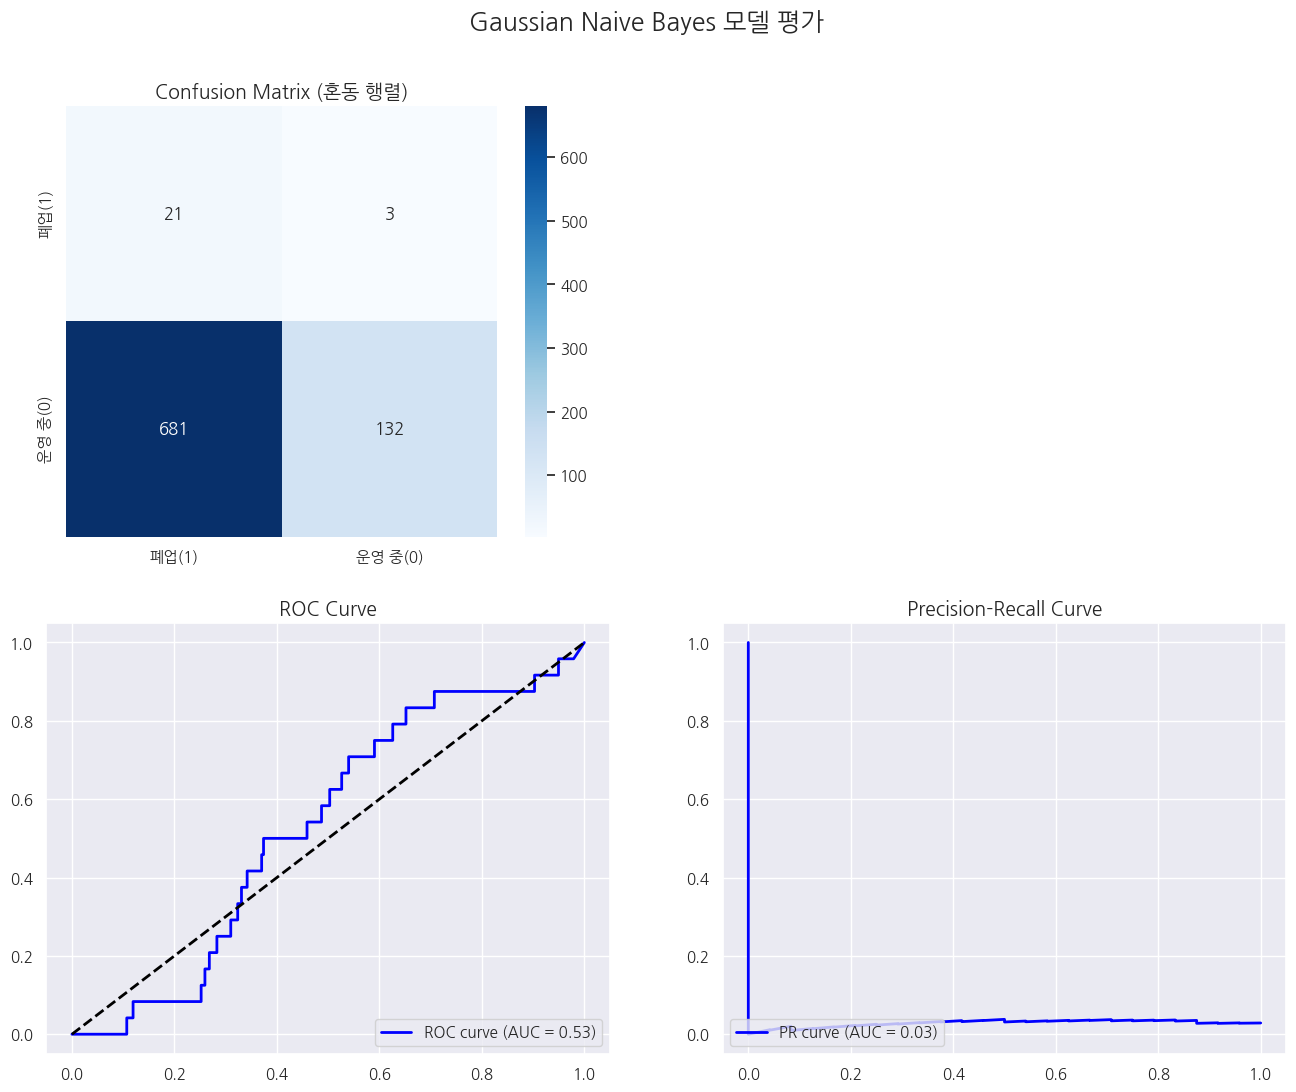

In [ ]:
# Gaussian Naive Bayes
model=GaussianNB()
model.fit(X_train,y_train)

#가우시안은 X 데이터에 .toarray() 붙이기
model_eval(model,"Gaussian Naive Bayes",X_test,y_test)

--- gnb 모델의 하이퍼파라미터 튜닝 시작 ---
100%|████████████████████████████████████| 50/50 [00:00<00:00, 56.70trial/s, best loss: -0.8823809523809525]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'var_smoothing': np.float64(1.9675490801855302e-10)}


최종 모델 학습 완료.
--- GNB 모델 평가 ---
정확도(Accuracy): 0.1673
정밀도(Precision): 0.0294
재현율(Recall): 0.8750
F1 점수(F1 Score): 0.0568
매튜 상관 계수(MCC): 0.0101



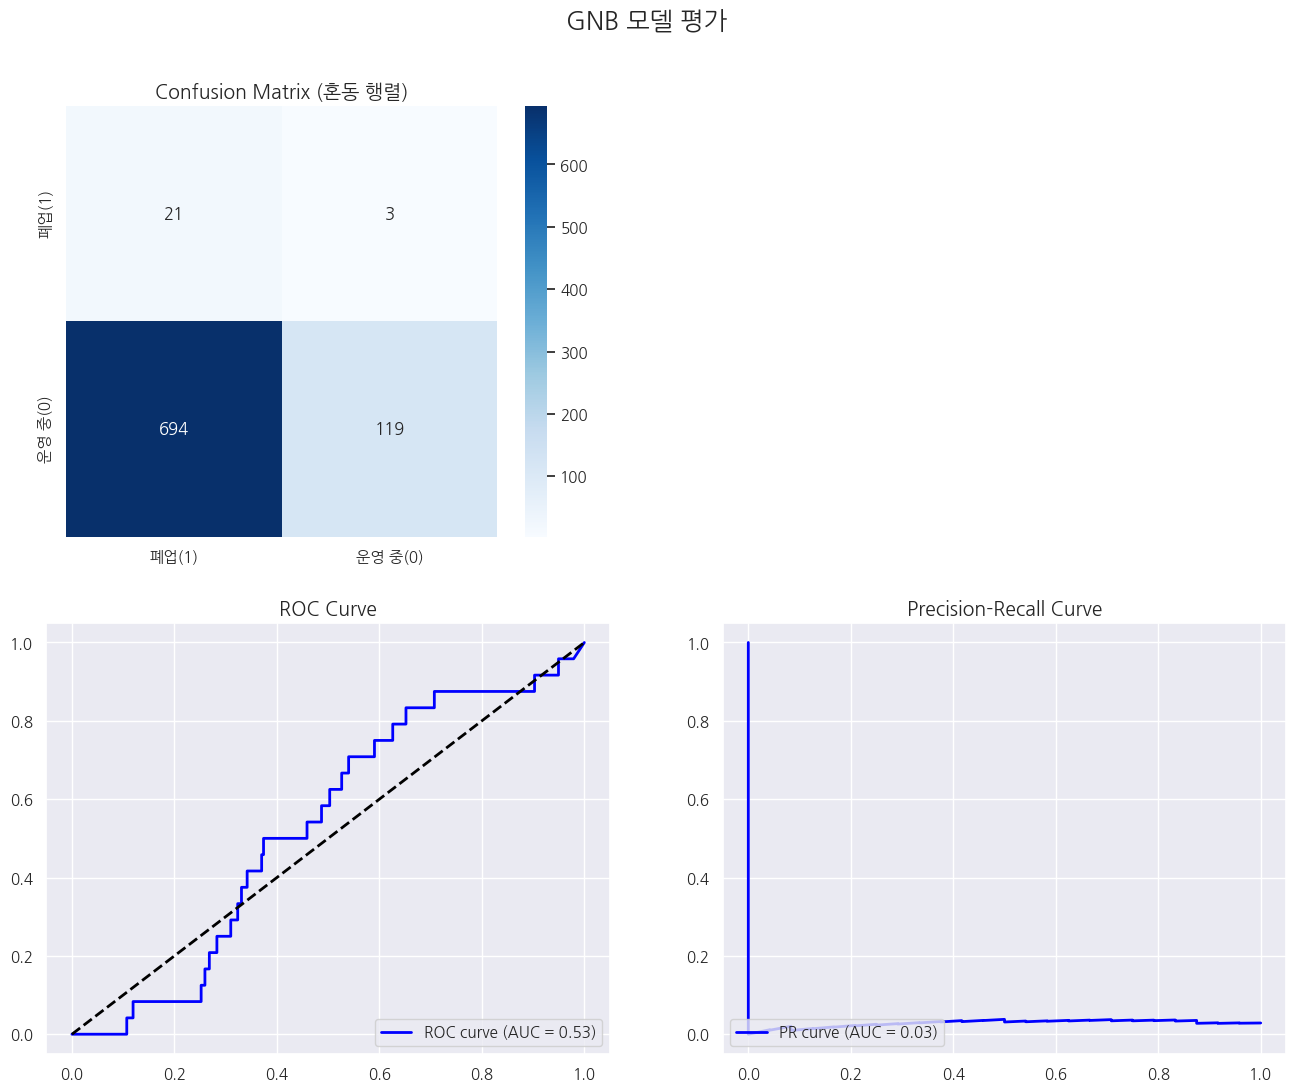

In [ ]:
ModelTuner('gnb',X_train, X_test,y_train,y_test).run()

### KNN(K-Nearest Neighbours)

--- K-Nearest Neighbours 모델 평가 ---
정확도(Accuracy): 0.9713
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



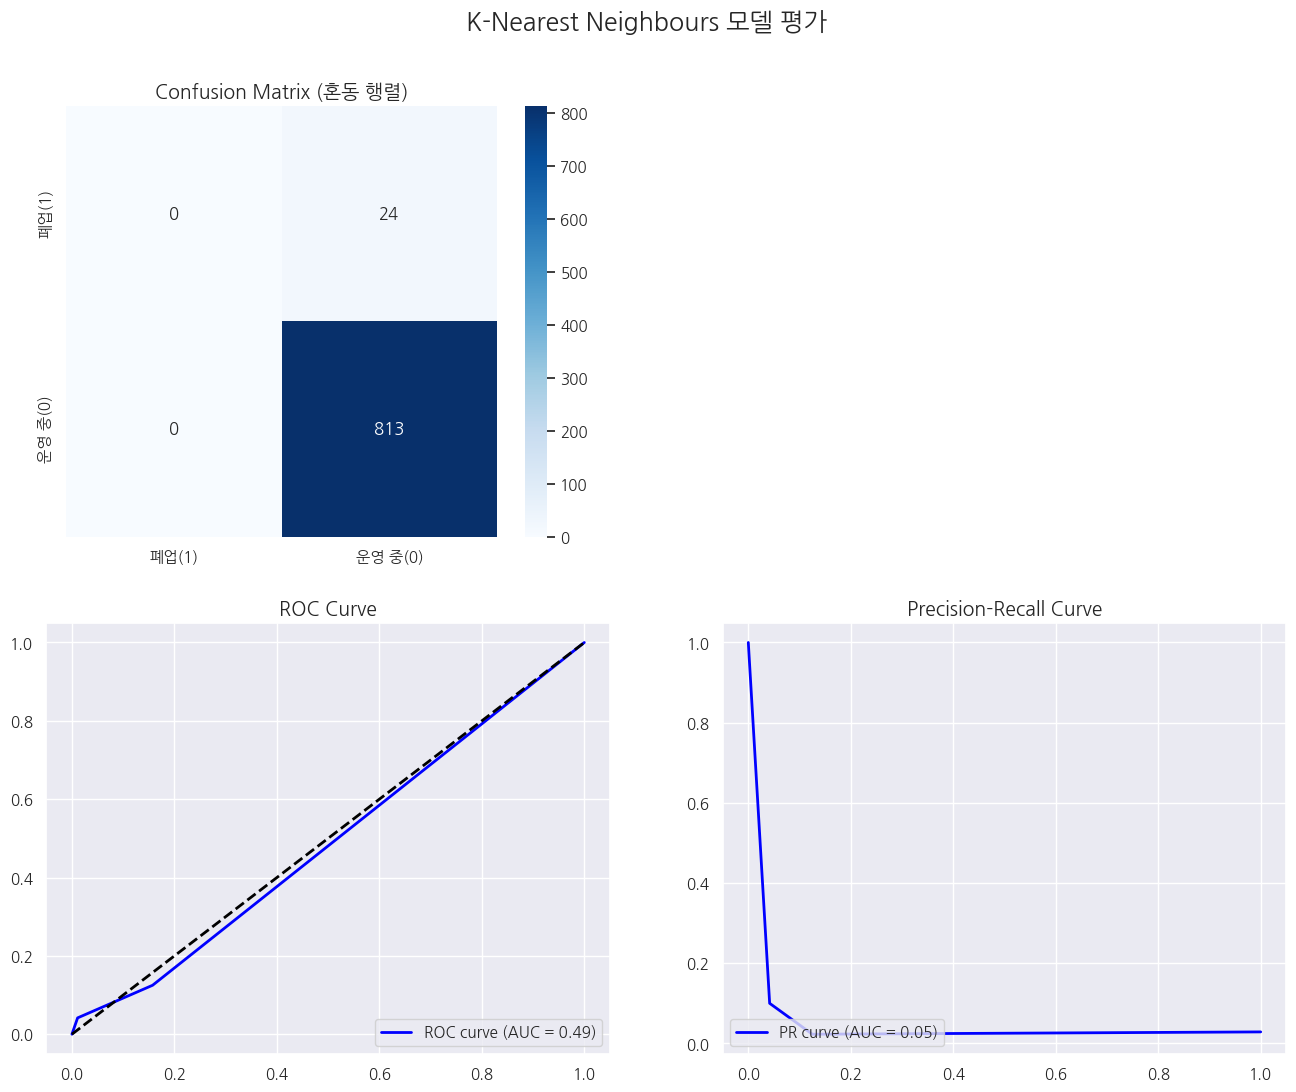

In [ ]:
#K-Nearest Neighbours(KNN)
model=KNeighborsClassifier() 
model.fit(X_train,y_train)

model_eval(model,"K-Nearest Neighbours",X_test,y_test)

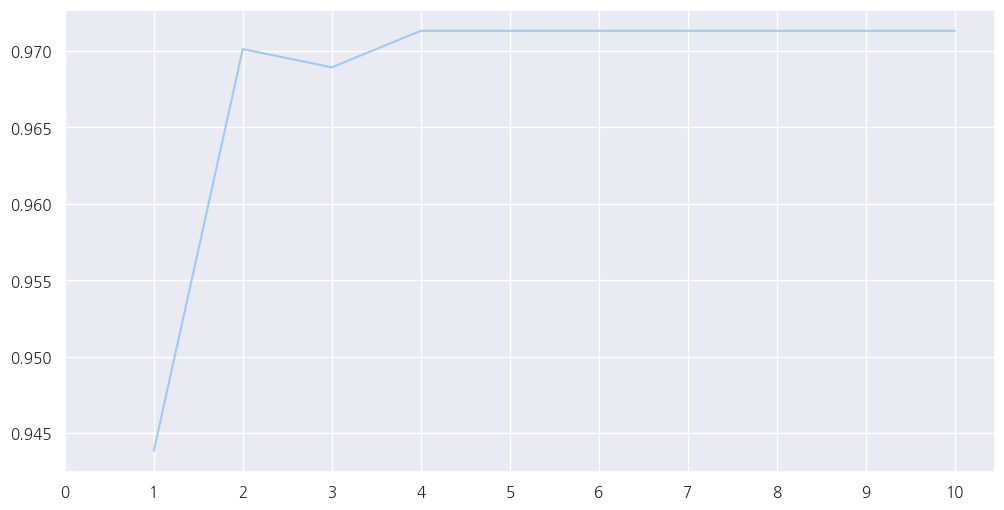

Accuracies for different values of n are: [0.94384707 0.97013142 0.96893668 0.97132616 0.97132616 0.97132616
 0.97132616 0.97132616 0.97132616 0.97132616] with the max value as  0.9713261648745519


In [ ]:
#KNN 모델에서 N-neighbours 수를 늘려가며 정확도를 계산
a_index=list(range(1,11))
a=pd.Series()
x=[0,1,2,3,4,5,6,7,8,9,10]
for i in list(range(1,11)):
    model=KNeighborsClassifier(n_neighbors=i) 
    model.fit(X_train,y_train)
    prediction=model.predict(X_test)
    score = pd.Series([metrics.accuracy_score(prediction,y_test)])
    a = pd.concat([a, score], ignore_index=True)
plt.plot(a_index, a)
plt.xticks(x)
fig=plt.gcf()
fig.set_size_inches(12,6)
plt.show()
print('Accuracies for different values of n are:',a.values,'with the max value as ',a.values.max())

--- knn 모델의 하이퍼파라미터 튜닝 시작 ---
100%|███████████████████████████████████████████████████| 50/50 [00:03<00:00, 13.70trial/s, best loss: -0.0]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'metric': 'minkowski', 'n_neighbors': np.float64(32.0), 'weights': 'uniform'}


최종 모델 학습 완료.
--- KNN 모델 평가 ---
정확도(Accuracy): 0.9713
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



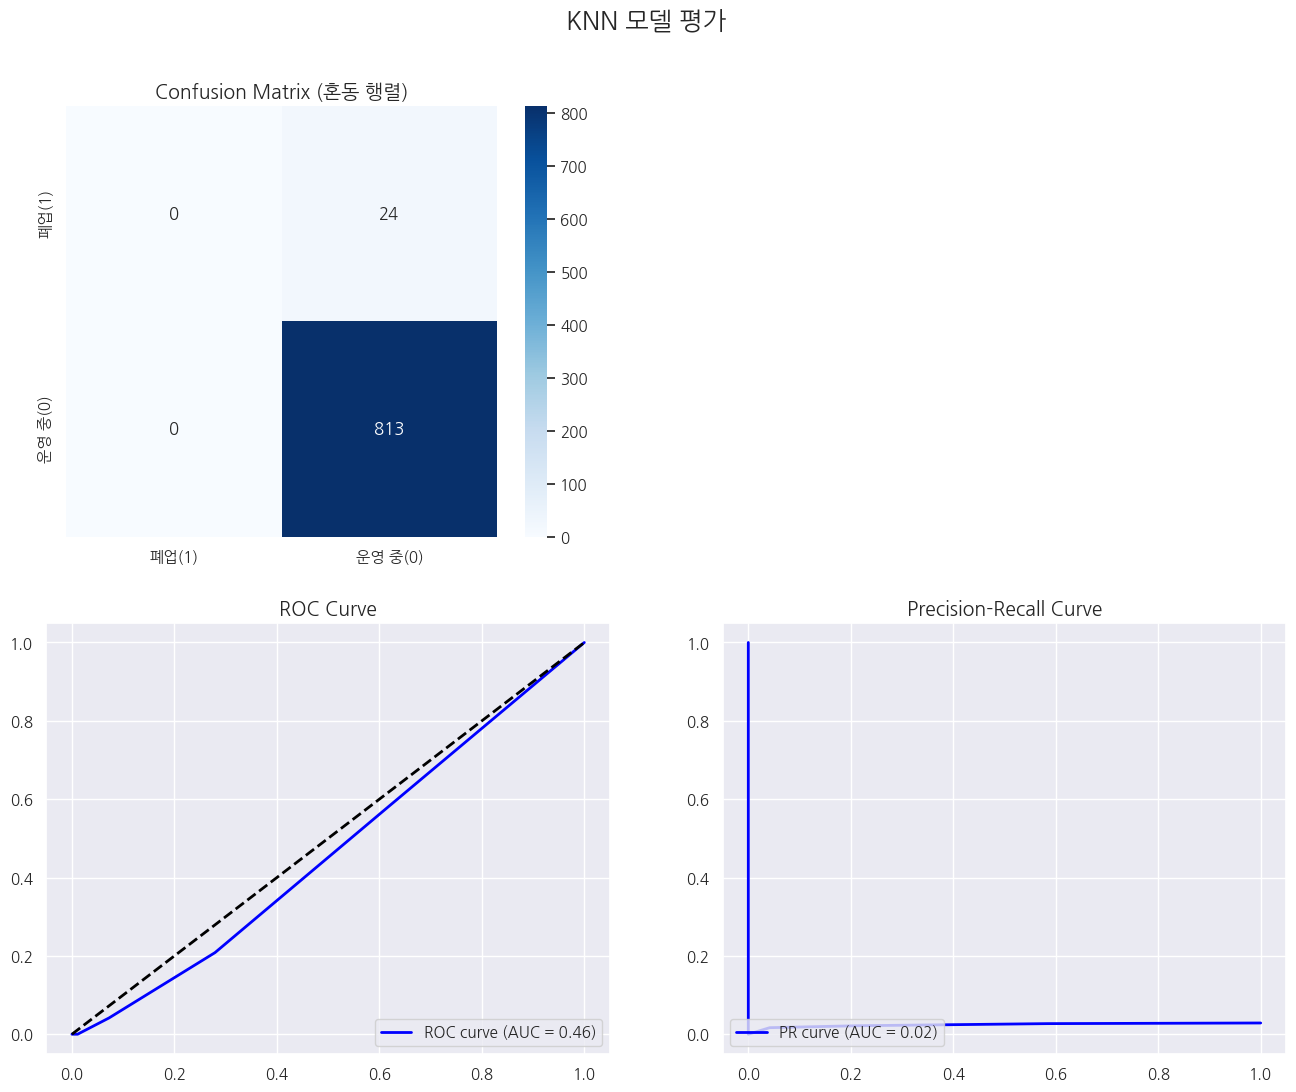

In [ ]:
ModelTuner('knn',X_train, X_test,y_train,y_test).run()

### Support Vector Machine

--- Linear Support Vector Machine 모델 평가 ---
정확도(Accuracy): 0.9713
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



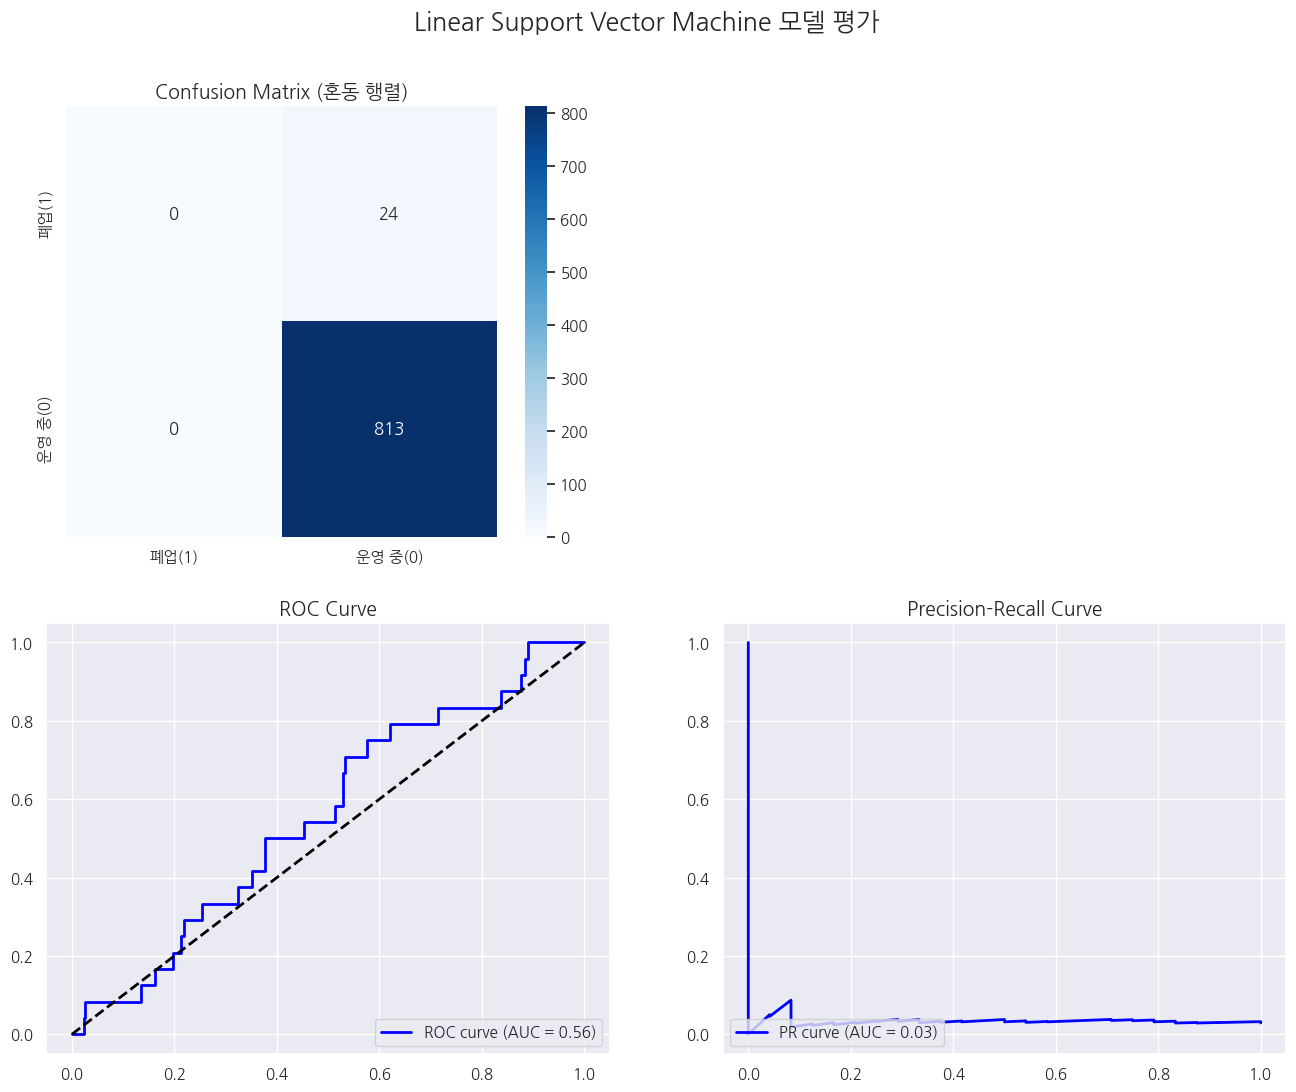

In [ ]:
#Linear Support Vector Machine(linear-SVM)
model=svm.SVC(probability=True,kernel='linear',C=0.1,gamma=0.1)
model.fit(X_train,y_train)

model_eval(model,"Linear Support Vector Machine",X_test,y_test)

In [ ]:
ModelTuner('svc_linear',X_train, X_test,y_train,y_test).run()

--- Radial Support Vector Machines 모델 평가 ---
정확도(Accuracy): 0.9713
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



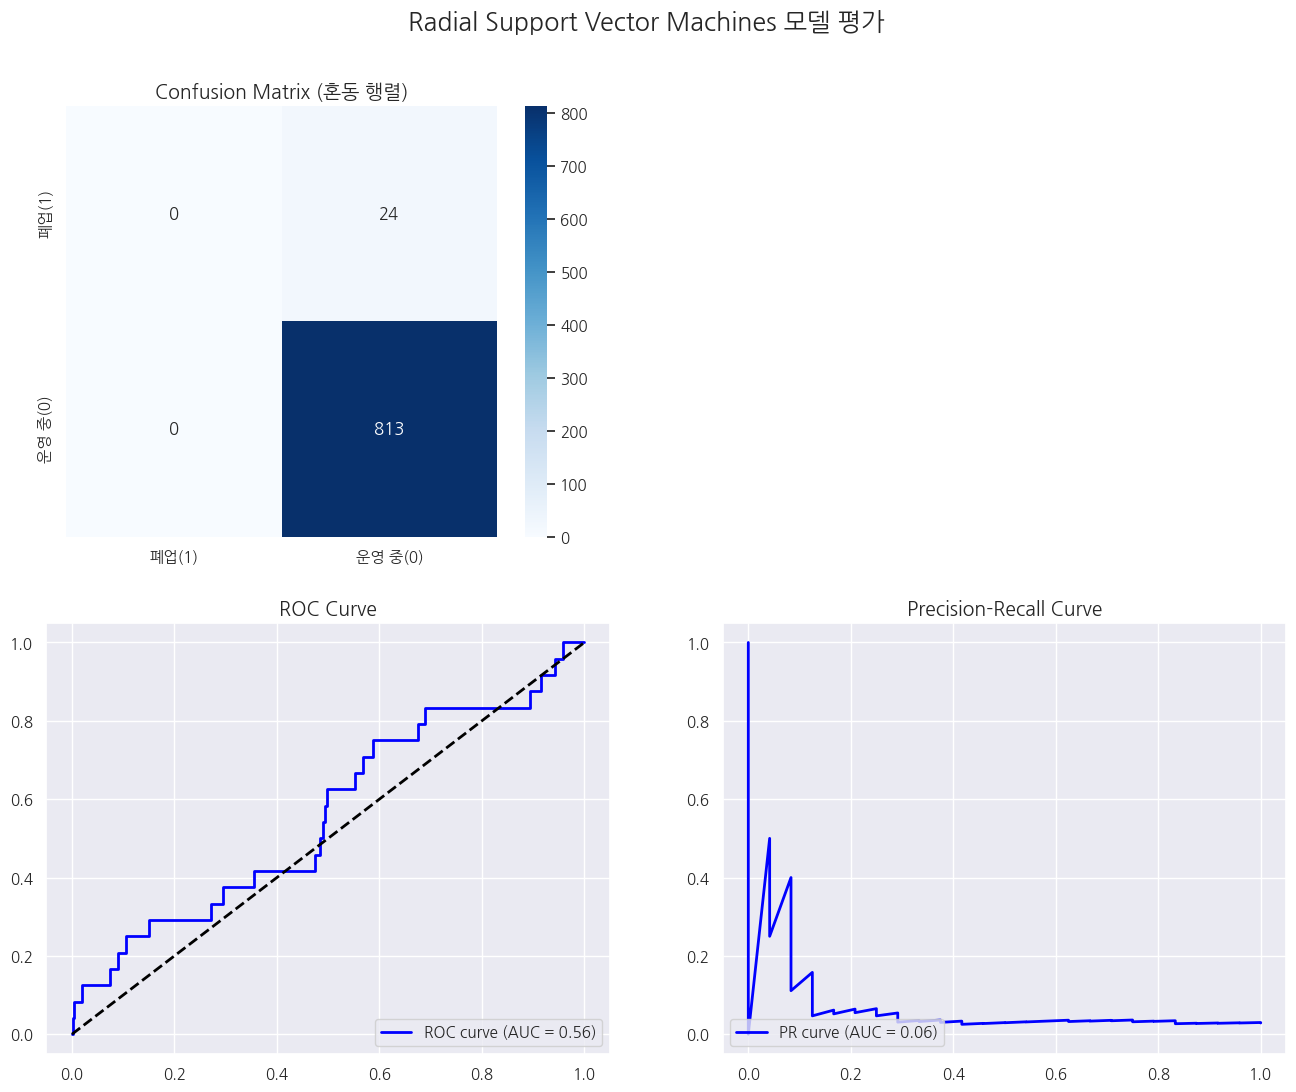

In [ ]:
#Radial Support Vector Machines(rbf-SVM)
model=svm.SVC(probability=True,kernel='rbf',C=1,gamma=0.1)
model.fit(X_train,y_train)

model_eval(model,"Radial Support Vector Machines",X_test,y_test)

--- svc_rbf 모델의 하이퍼파라미터 튜닝 시작 ---
100%|███████████████████████████████████████████████████| 50/50 [03:09<00:00,  3.78s/trial, best loss: -1.0]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'C': np.float64(0.022667696660035788), 'class_weight': 'balanced', 'gamma': np.float64(0.00018607657136529177)}


최종 모델 학습 완료.
--- SVC_RBF 모델 평가 ---
정확도(Accuracy): 0.0287
정밀도(Precision): 0.0287
재현율(Recall): 1.0000
F1 점수(F1 Score): 0.0557
매튜 상관 계수(MCC): 0.0000



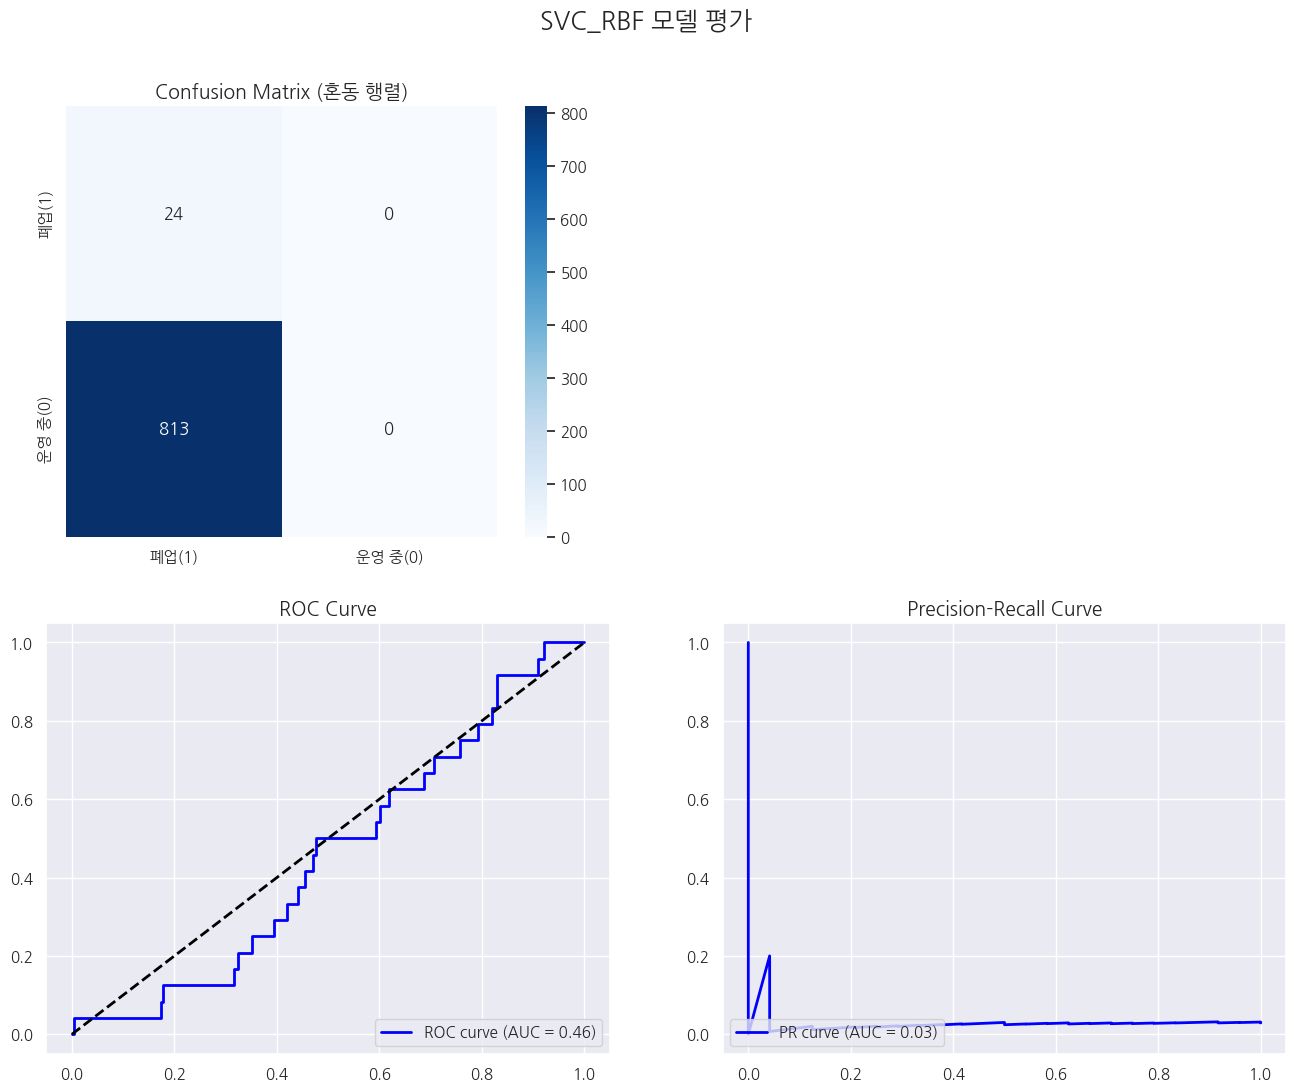

[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_spl

In [ ]:
ModelTuner('svc_rbf',X_train, X_test,y_train,y_test).run()

### Light Gradient Boosting Machine

[LightGBM] [Warning] Using sparse features with CUDA is currently not supported.
[LightGBM] [Info] Number of positive: 89, number of negative: 2545
[LightGBM] [Info] Total Bins 3571
[LightGBM] [Info] Number of data points in the train set: 2634, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[160]	training's binary_logloss: 0.0221338	valid_1's binary_logloss: 0.152943
--- Light Gradient Boosting Machine 모델 평가 ---
정확도(Accuracy): 0.9721
정밀도(Precision): 0.1111
재현율(Recall): 0.0625
F1 점수(F1 Score): 0.0800
매튜 상관 계수(MCC): 0.0698



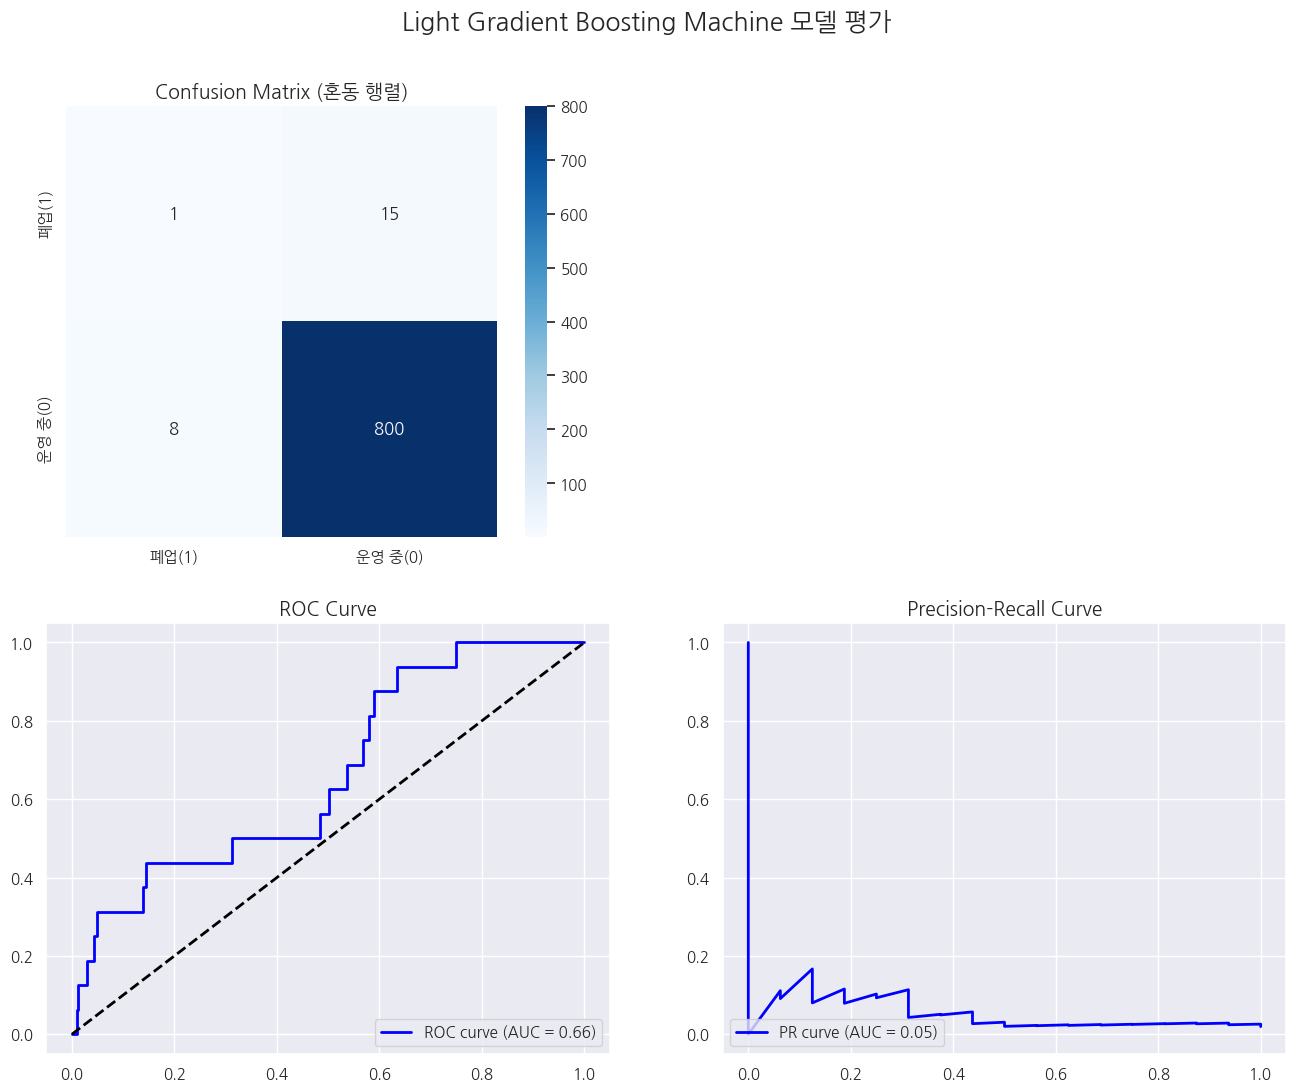

In [29]:
X_tr_dense = X_tr.to_numpy()
X_val_dense = X_val.to_numpy()
X_test_dense = X_test.to_numpy()
y_tr_dense = y_tr.to_numpy()
y_val_dense = y_val.to_numpy()
y_test_dense = y_test.to_numpy()


#GPU 사용안되면 device='cuda' 지우기
lgb_model = LGBMClassifier(
    device='cuda',
    n_estimators=500,
    learning_rate=0.05,
    class_weight = "balanced", #가중치추가
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    #is_unbalance=True
)

lgb_model.fit(
    X_tr_dense, y_tr_dense,
    eval_set=[(X_tr_dense, y_tr_dense), (X_val_dense, y_val_dense)]
    ,callbacks=[lgbm.early_stopping(stopping_rounds=50, verbose=-1)]
)

model_eval(lgb_model,"Light Gradient Boosting Machine",X_test_dense,y_test_dense)

--- lgbm 모델의 하이퍼파라미터 튜닝 시작 ---
100%|███████████████████████████████████████████████████| 50/50 [05:18<00:00,  6.37s/trial, best loss: -0.0]
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'colsample_bytree': np.float64(0.7936739623353964), 'learning_rate': np.float64(0.02639565625679032), 'max_depth': np.float64(12.0), 'min_child_samples': np.float64(30.0), 'n_estimators': np.float64(1600.0), 'num_leaves': np.float64(105.0), 'reg_alpha': np.float64(0.8839266254726155), 'reg_lambda': np.float64(0.620118997676641), 'subsample': np.float64(0.9254621630561151)}


최종 모델 학습 완료.
--- LGBM 모델 평가 ---
정확도(Accuracy): 0.9713
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): 0.0000



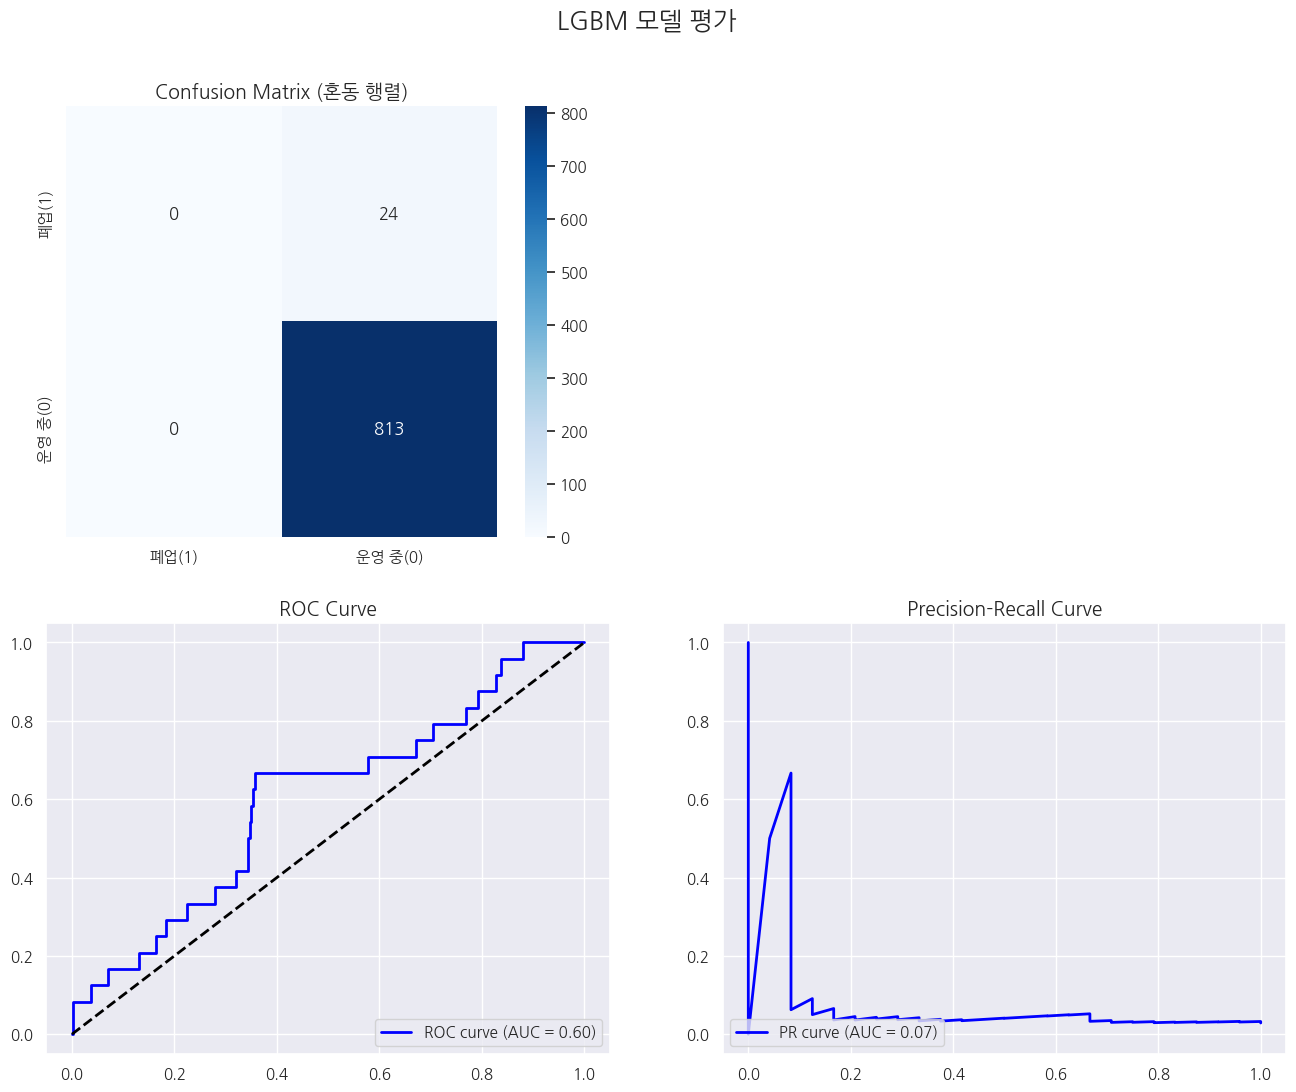

In [ ]:
ModelTuner('lgbm',X_train, X_test,y_train,y_test).run()

### Exreme Gradient Boosting

--- Exreme Gradient Boosting 모델 평가 ---
정확도(Accuracy): 0.9709
정밀도(Precision): 0.0000
재현율(Recall): 0.0000
F1 점수(F1 Score): 0.0000
매튜 상관 계수(MCC): -0.0139



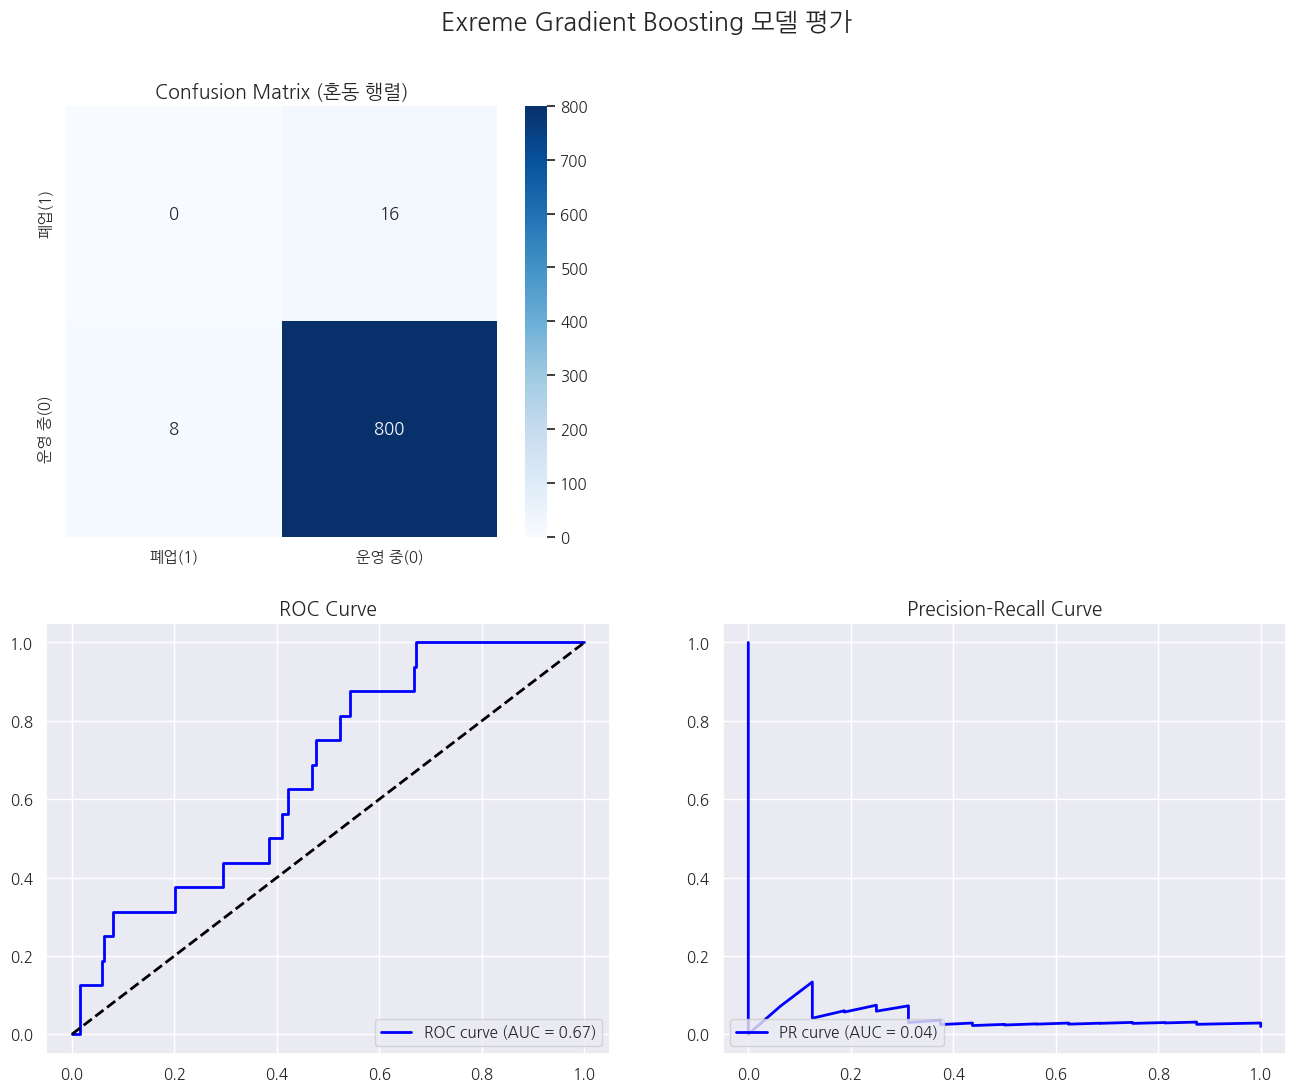

In [24]:
#GPU 사용안되면 tree_method = "hist", device = "cuda" 지우기
xgb_model = XGBClassifier(tree_method = "hist", device = "cuda",
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    early_stopping_rounds=50                      
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=False
)

model_eval(xgb_model,"Exreme Gradient Boosting",X_test,y_test)

--- xgb 모델의 하이퍼파라미터 튜닝 시작 ---
  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 50/50 [06:42<00:00,  8.05s/trial, best loss: -0.3461904761904762] 
--- 튜닝 완료 ---
########최적의 하이퍼파라미터########
{'colsample_bytree': np.float64(0.7649634480728088), 'gamma': np.float64(0.2955441426044862), 'learning_rate': np.float64(0.02099120208647278), 'max_depth': np.float64(4.0), 'min_child_weight': np.float64(10.0), 'n_estimators': np.float64(100.0), 'scale_pos_weight': np.float64(36.3235337897335), 'subsample': np.float64(0.6929842549878388)}


최종 모델 학습 완료.
--- XGB 모델 평가 ---
정확도(Accuracy): 0.8217
정밀도(Precision): 0.0652
재현율(Recall): 0.3913
F1 점수(F1 Score): 0.1118
매튜 상관 계수(MCC): 0.0998



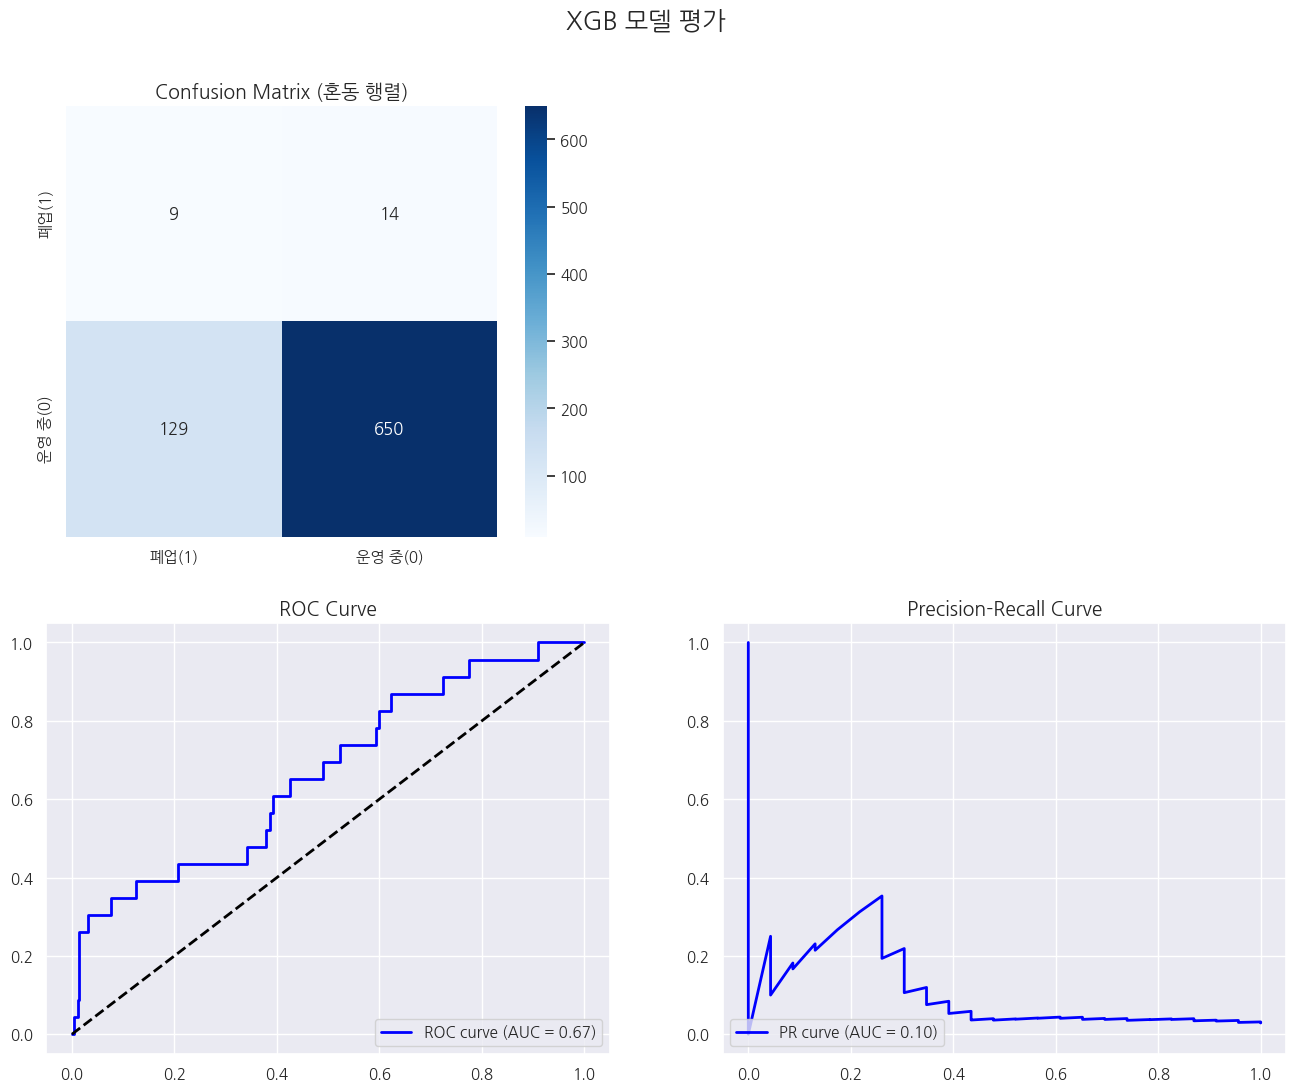

In [79]:
ModelTuner('xgb',X_train, X_test,y_train,y_test).run()

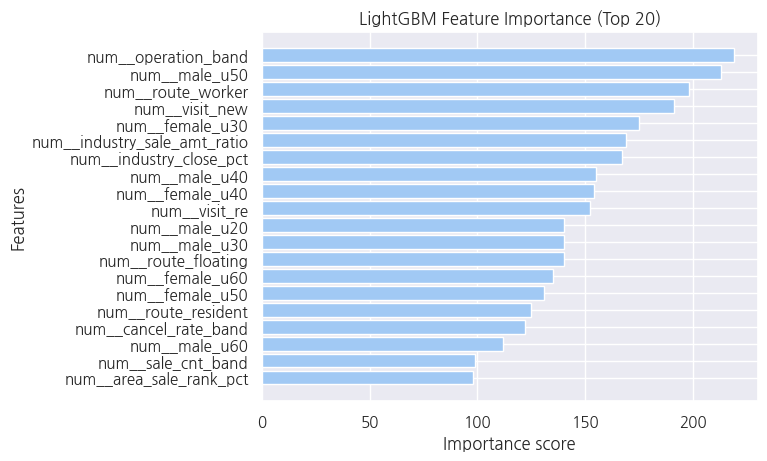

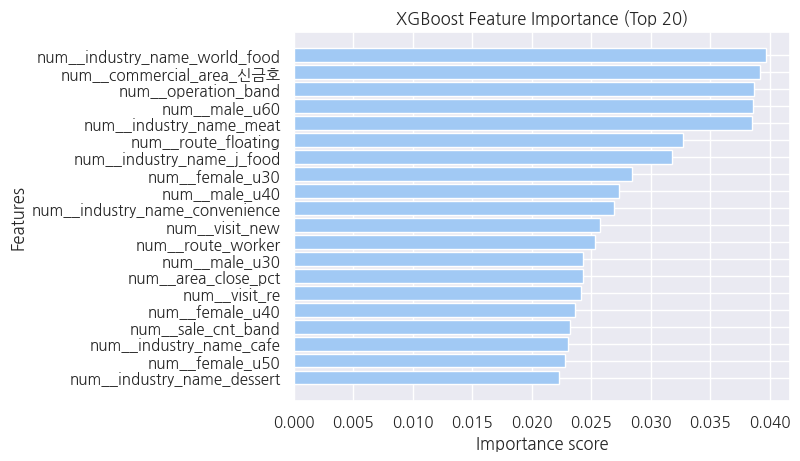

In [ ]:
def plot_feature_importance(model_name, features, importances, top_n=20):
    idx = np.argsort(importances)[::-1][:top_n]
    plt.barh(np.array(features)[idx][::-1], np.array(importances)[idx][::-1])
    plt.title(f"{model_name} Feature Importance (Top {top_n})")
    plt.xlabel("Importance score")
    plt.ylabel("Features")
    plt.show()


# LightGBM
fi_lgb = lgb_model.feature_importances_
plot_feature_importance("LightGBM", X_val.columns, fi_lgb)

# XGBoost
fi_xgb = xgb_model.feature_importances_  # numpy array
plot_feature_importance("XGBoost", X_val.columns, fi_xgb)

# CatBoost
# fi_cat = cat_model.get_feature_importance()
# plot_feature_importance("CatBoost", X_val.columns, fi_cat)

                           feature  importance
0              num__operation_band         0.0
1               num__sale_cnt_band         0.0
2                    num__aov_band         0.0
3            num__cancel_rate_band         0.0
4  num__delivery_sale_amount_ratio         0.0
5     num__industry_sale_amt_ratio         0.0
6          num__area_sale_rank_pct         0.0
7          num__industry_close_pct         0.0
8              num__area_close_pct         0.0
9                    num__male_u20         0.0


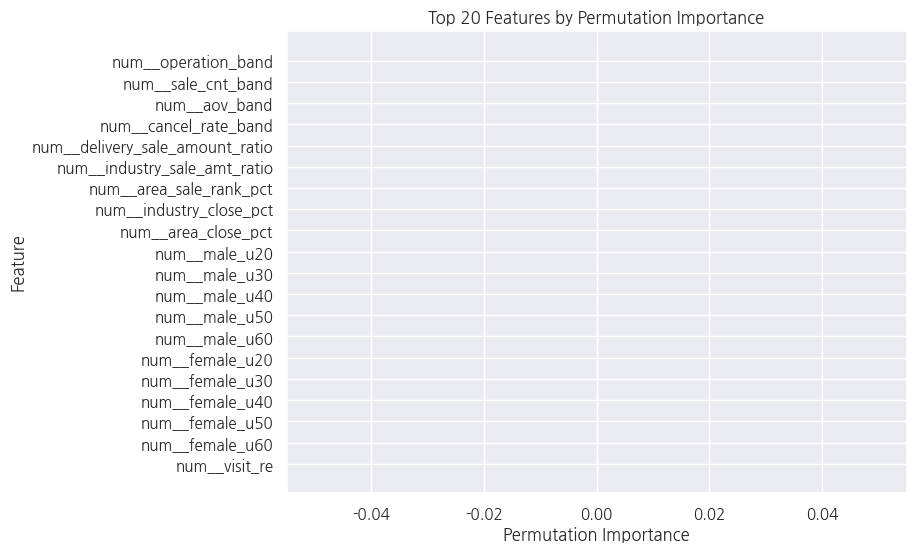

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    lgb_model, X_val, y_val,
    scoring="f1",
    n_repeats=1,
    random_state=42,
    n_jobs=-1
    
)

import pandas as pd

fi = pd.DataFrame({
    "feature": X_val.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

print(fi.head(10))

top_features = fi.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"], color="skyblue")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features by Permutation Importance")
plt.gca().invert_yaxis() 
plt.show()

                           feature  importance
0              num__operation_band         0.0
1               num__sale_cnt_band         0.0
2                    num__aov_band         0.0
3            num__cancel_rate_band         0.0
4  num__delivery_sale_amount_ratio         0.0
5     num__industry_sale_amt_ratio         0.0
6          num__area_sale_rank_pct         0.0
7          num__industry_close_pct         0.0
8              num__area_close_pct         0.0
9                    num__male_u20         0.0


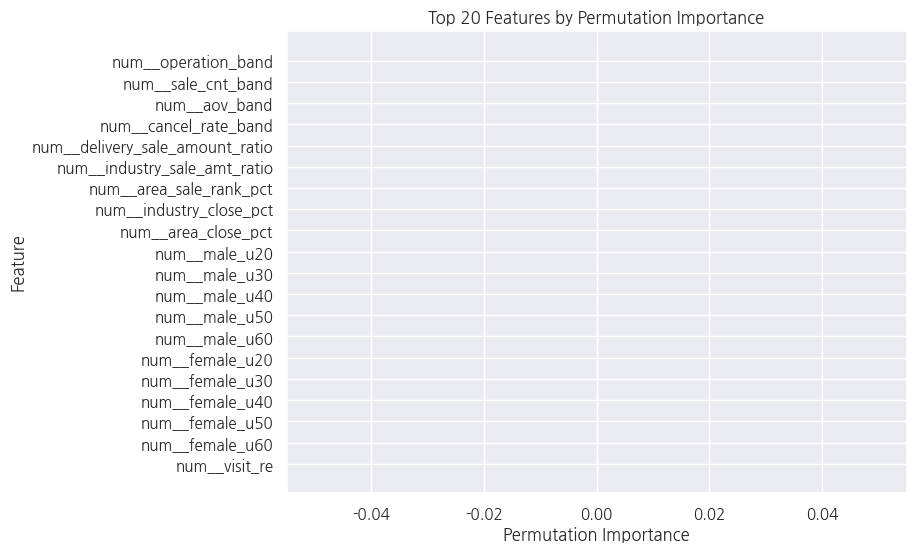

In [ ]:
result_xgb = permutation_importance(
    xgb_model, X_val, y_val,
    scoring="f1",
    n_repeats=1,
    random_state=42,
    n_jobs=-1
     
)

fi_xgb = pd.DataFrame({
    "feature": X_val.columns,
    "importance": result_xgb.importances_mean
}).sort_values(by="importance", ascending=False)

print(fi_xgb.head(10))

top_features_xgb = fi_xgb.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top_features_xgb["feature"], top_features_xgb["importance"], color="skyblue")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features by Permutation Importance")
plt.gca().invert_yaxis() 
plt.show()

## 비지도 학습

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

numerical_features = final_df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = final_df.select_dtypes(exclude=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features), # 숫자형 컬럼은 StandardScaling
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False), categorical_features)  # 범주형 컬럼은 OneHotEncoding
    ])

final_df_prc = preprocessor.fit_transform(final_df)

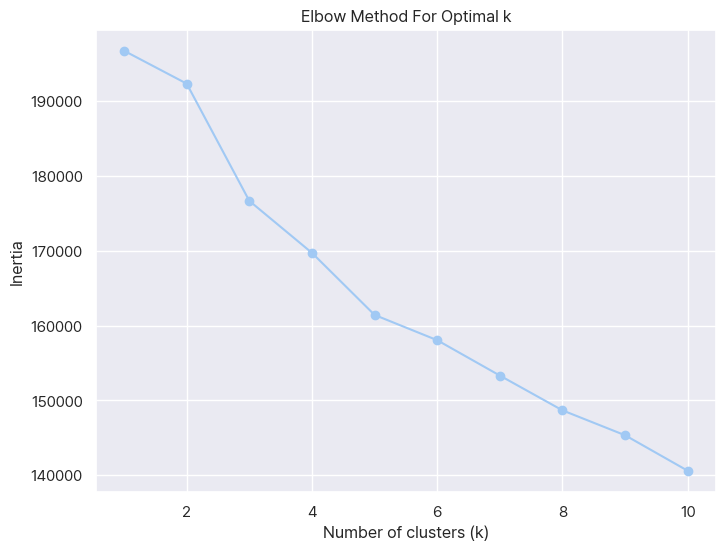

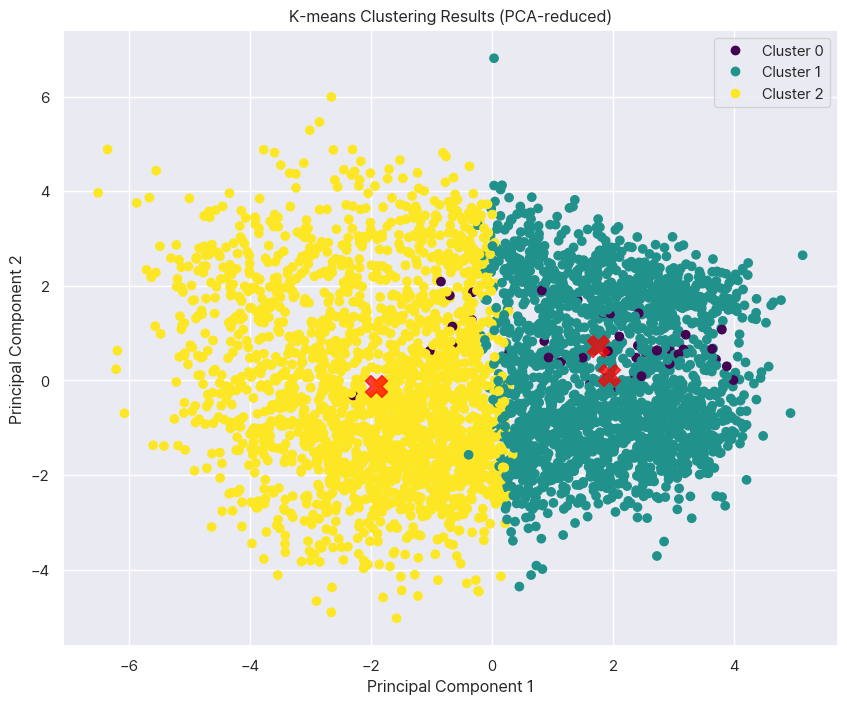

In [ ]:
# k-means clustering

inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(final_df_prc)
    inertia.append(kmeans.inertia_)

# Elbow Method 
plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(final_df_prc)

#PCA를 사용하여 2차원으로 차원 축소 후 시각화
#클러스터의 중심을 빨간색 'X'로 표시
pca = PCA(n_components=2)
principal_components = pca.fit_transform(final_df_prc)


plt.figure(figsize=(10, 8))
scatter = plt.scatter(principal_components.iloc[:, 0], principal_components.iloc[:, 1], c=cluster_labels, cmap='viridis', marker='o')

centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers.iloc[:, 0], centers.iloc[:, 1], c='red', s=250, alpha=0.75, marker='X')
plt.title('K-means Clustering Results (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=[f'Cluster {i}' for i in range(optimal_k)])
plt.grid(True)
plt.show()

In [ ]:
len((principal_components.iloc[:, 0]))

4185

For n_clusters = 2, the average silhouette_score is : 0.2816


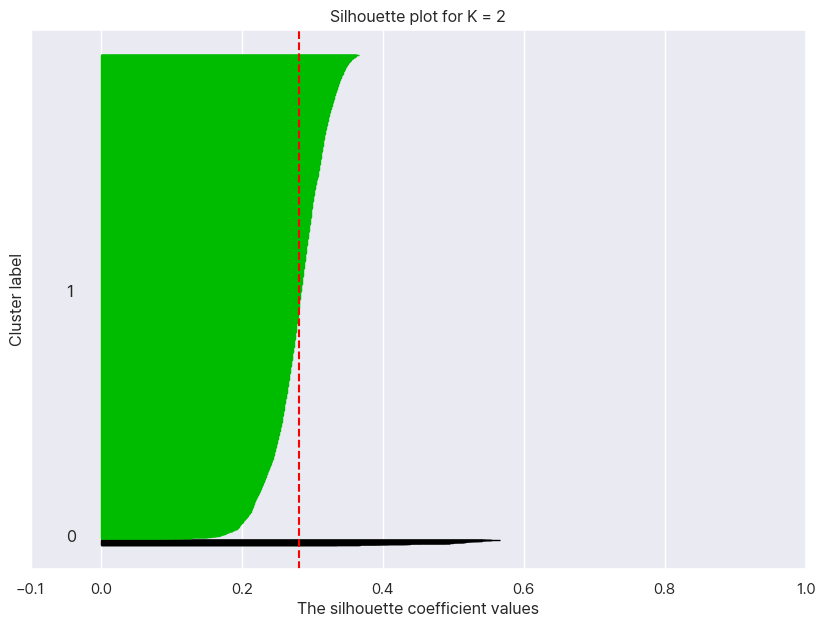

For n_clusters = 3, the average silhouette_score is : 0.0871


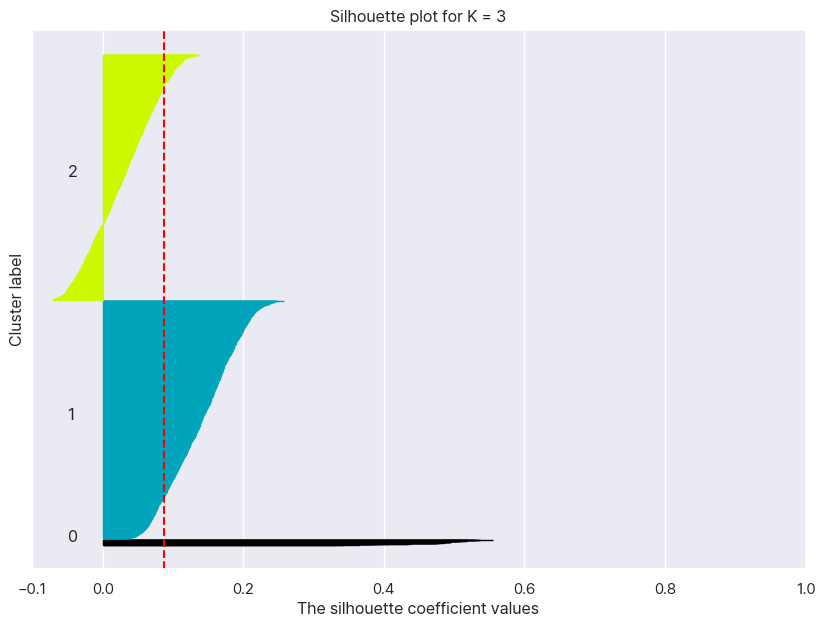

For n_clusters = 4, the average silhouette_score is : 0.0656


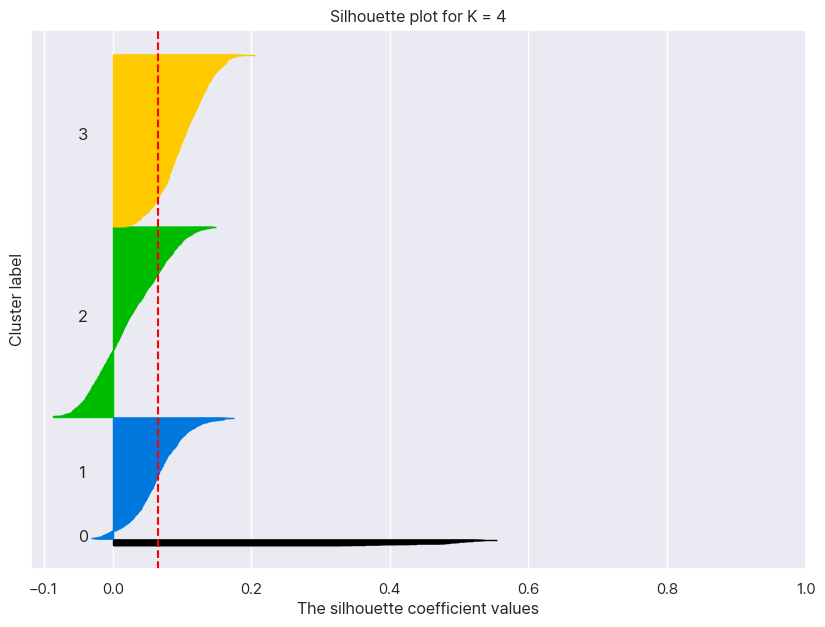

For n_clusters = 5, the average silhouette_score is : 0.0812


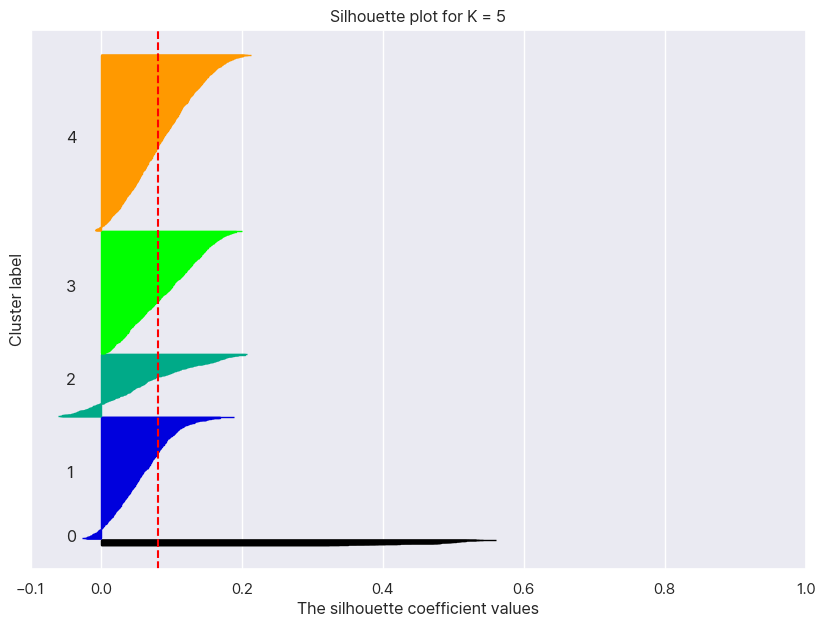

For n_clusters = 6, the average silhouette_score is : 0.0766


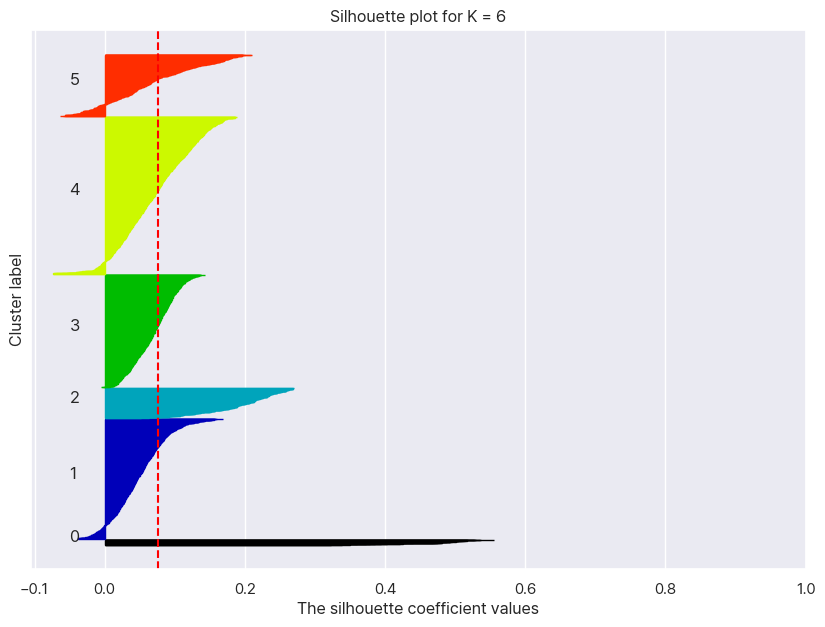

For n_clusters = 7, the average silhouette_score is : 0.0814


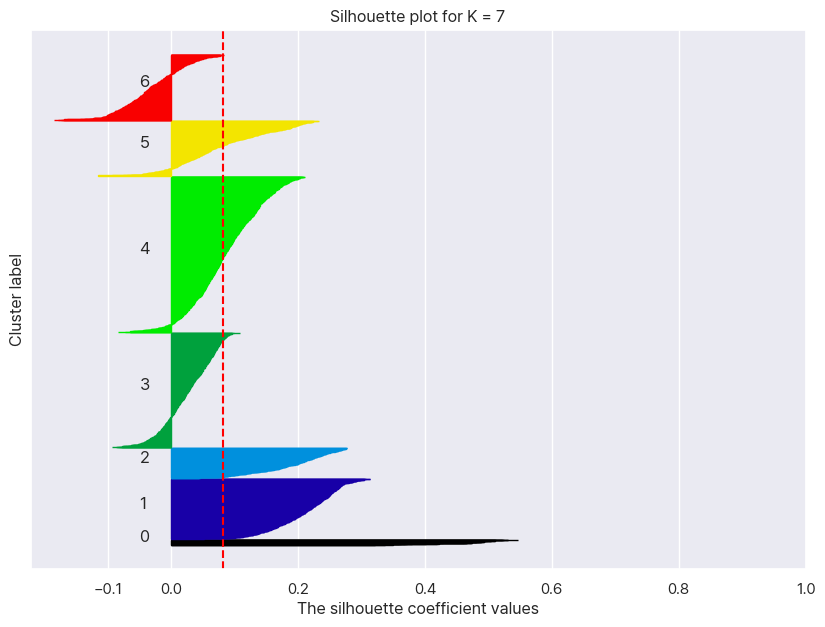

For n_clusters = 8, the average silhouette_score is : 0.0845


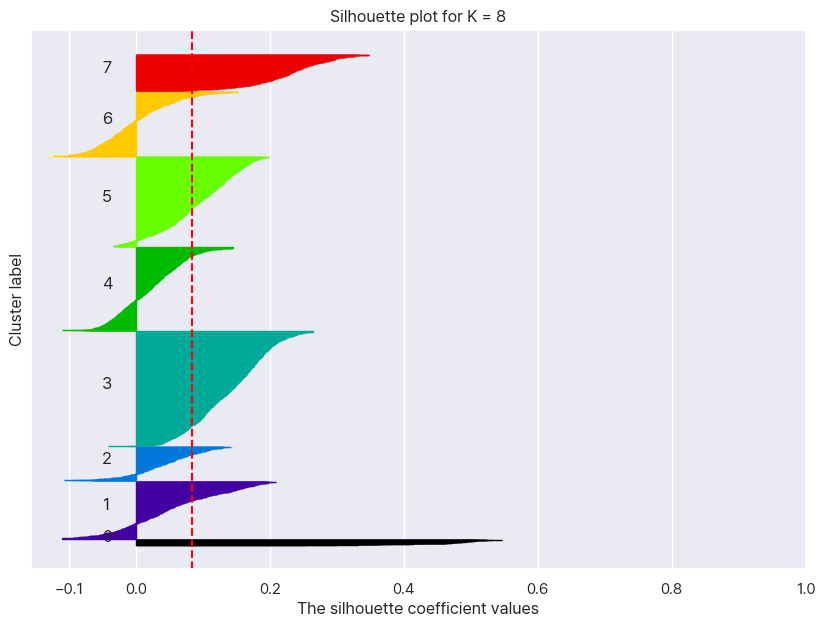

For n_clusters = 9, the average silhouette_score is : 0.0822


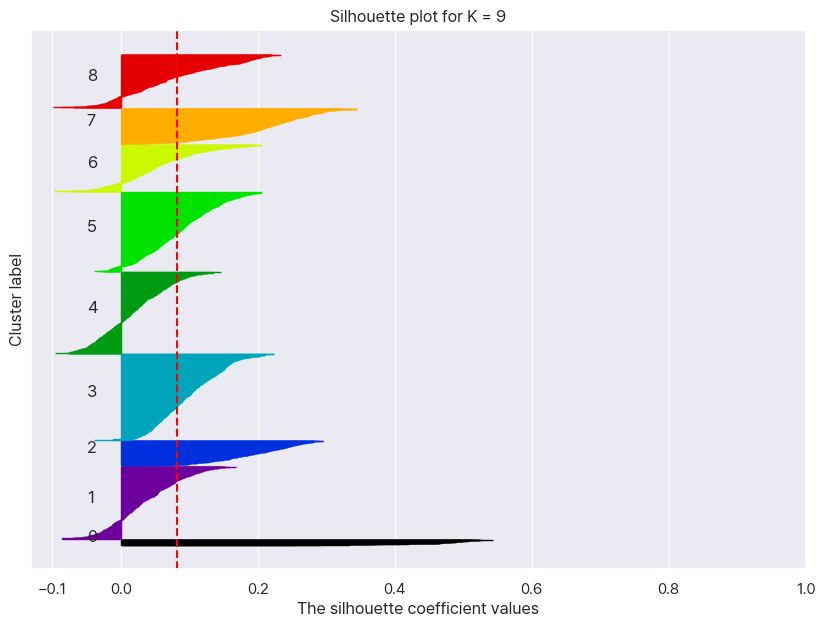

For n_clusters = 10, the average silhouette_score is : 0.0995


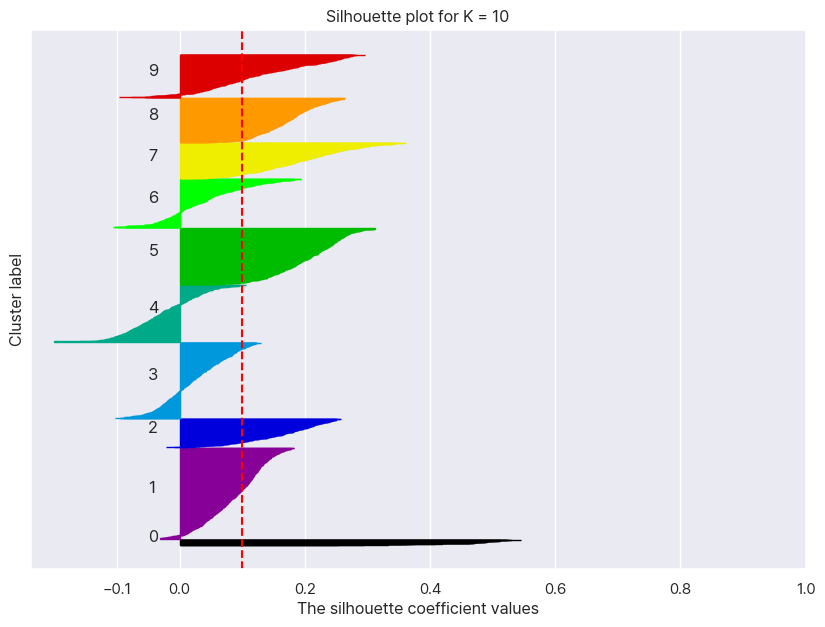

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score


for k in range(2, 11):

    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(10, 7)


    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(final_df_prc)
    silhouette_vals = silhouette_samples(final_df_prc, kmeans.labels_)
    avg_silhouette_score = silhouette_score(final_df_prc, kmeans.labels_)
    print(f"For n_clusters = {k}, the average silhouette_score is : {avg_silhouette_score:.4f}")
    
    y_lower = 10  
    

    for c_num in range(k):

        cluster_silhouette_vals = silhouette_vals[kmeans.labels_ == c_num]
        cluster_silhouette_vals.sort()
        
        cluster_size = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + cluster_size
        color = cm.nipy_spectral(float(c_num) / k)
        
        ax.barh(range(y_lower, y_upper), 
                cluster_silhouette_vals, 
                facecolor=color, 
                edgecolor=color,
                height=1.0)
        
        ax.text(-0.05, y_lower + 0.5 * cluster_size, str(c_num))
        y_lower = y_upper + 10  # 다음 클러스터와의 여백

    ax.set_title(f"Silhouette plot for K = {k}")
    ax.set_xlabel("The silhouette coefficient values")
    ax.set_ylabel("Cluster label")


    ax.axvline(x=avg_silhouette_score, color="red", linestyle="--")
    
    ax.set_yticks([])  
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.show()

In [ ]:
final_df_prc['cluster'] = cluster_labels

# 각 클러스터별로 모든 피쳐의 평균값을 계산하여 비교
cluster_feature_means = final_df_prc.groupby('cluster').mean()

# 보기 쉽게 행과 열을 전환(.T)하여 출력
print(cluster_feature_means.T)

cluster                                 0         1         2
num__operation_band              0.371235  0.281648 -0.281245
num__sale_cnt_band              -0.502799 -0.401752  0.400617
num__aov_band                    0.140493  0.063561 -0.064658
num__cancel_rate_band            0.074899  0.309857 -0.302430
num__delivery_sale_amount_ratio  0.374054 -0.095052  0.084458
num__industry_sale_amt_ratio     0.271262  0.243105 -0.241727
num__area_sale_rank_pct         -0.294182 -0.079339  0.083196
num__industry_close_pct          0.312935  0.182115 -0.183381
num__area_close_pct             -0.067746  0.140959 -0.135447
num__male_u20                    0.169479  0.633395 -0.618555
num__male_u30                    0.091871  0.383297 -0.374093
num__male_u40                   -0.133020 -0.306163  0.300060
num__male_u50                   -0.544109 -0.513891  0.510366
num__male_u60                   -0.553418 -0.546169  0.541902
num__female_u20                  0.535365  0.649736 -0.642083
num__fem

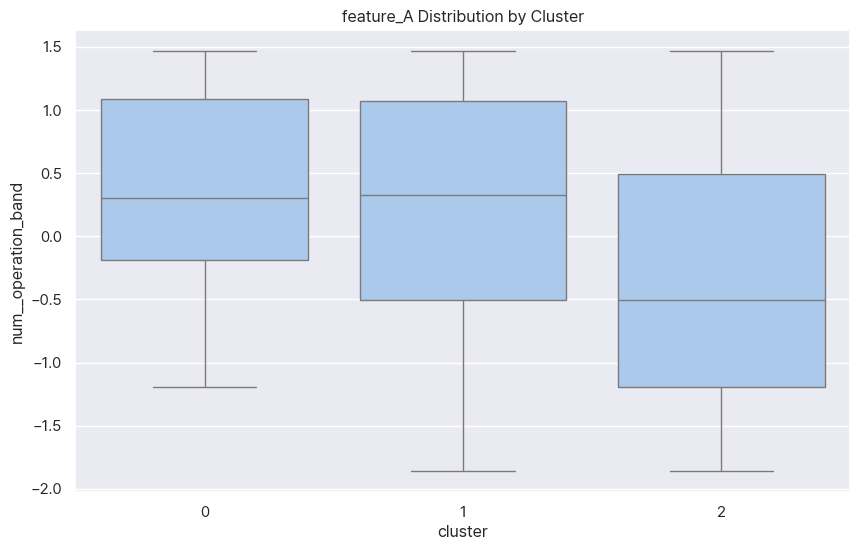

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='num__operation_band', data=final_df_prc)
plt.title('feature_A Distribution by Cluster')
plt.show()

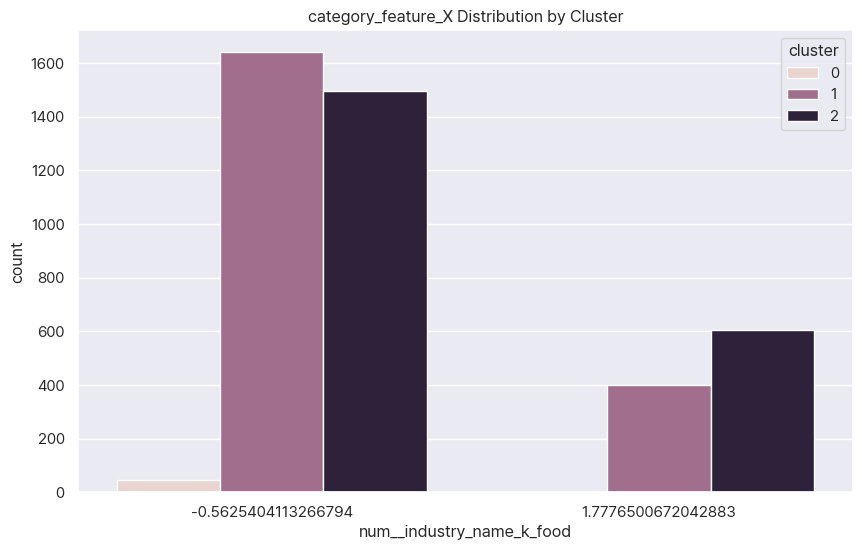

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='num__industry_name_k_food', hue='cluster', data=final_df_prc)
plt.title('category_feature_X Distribution by Cluster')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='num__is_closed', hue='cluster', data=final_df_prc)
plt.title('category_feature_X Distribution by Cluster')
plt.show()

ValueError: Could not interpret value `cluster` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

### Deep Learning